# Miniproyecto 1 - De la bolsa de palabras a los transformers

## Clasificación de polaridad en reseñas turísticas en español

**Maestría · Universidad Icesi · Procesamiento de Lenguaje Natural**

Autores: Juan José Aguado · Juan David Cruz · Juan Diego Ramírez

---

> **Cómo leer este notebook.** Cada sección de modelado va precedida de la pregunta que
> intenta responder y cerrada con lo que efectivamente encontramos. Las gráficas no están
> de adorno: cada una induce una decisión posterior, y esa cadena se hace explícita en la
> síntesis del análisis exploratorio (§3.8).

## 0. El problema

Dada una reseña turística escrita en español por un visitante sobre un destino mexicano, el objetivo de este proyecto es predecir la **polaridad** que el autor asignó (de 1 a 5 estrellas) basándonos únicamente en el texto de la reseña.

Este **no es un problema trivial resuelto de análisis de sentimiento** debido a cuatro factores clave del mundo real:
1. **Ordinalidad:** El error de clasificar una reseña de 1 estrella como si fuera de 5 estrellas es drásticamente peor que clasificarla como de 2 estrellas.
2. **Desbalance extremo:** La inmensa mayoría de las reseñas turísticas son positivas (5 estrellas), lo que invalida métricas tradicionales como el *Accuracy*.
3. **Sesgo geográfico:** Existe un gran peso en la región de Quintana Roo; un modelo podría simplemente memorizar localizaciones en lugar de aprender el verdadero sentimiento.
4. **Vocabulario de dominio:** Las reseñas contienen jergas locales, espanglish y términos turísticos (ej. *sargazo*, *camastro*, *mesero*, *all inclusive*) que escapan al vocabulario general.

Para aislar qué aporta cada nivel de modelado a este desafío, adoptaremos una propuesta de cuatro representaciones (escalera de complejidad): comenzaremos con un baseline de bolsa de palabras dispersa (TF-IDF), subiremos a representaciones secuenciales aprendidas desde cero (LSTM) y finalizaremos con embeddings pre-entrenados del idioma (BiLSTM + spaCy).

### Mapa del notebook

| Sección | Contenido |
|---|---|
| 1 | Entorno, reproducibilidad y configuración adaptativa |
| 2 | Carga del corpus |
| 3 | Análisis exploratorio - y las decisiones que induce |
| 4 | Preprocesamiento, tokenización y protocolo experimental |
| 5–8 | Los cuatro modelos: TF-IDF, LSTM, BiLSTM+spaCy, BETO |
| 9–12 | Extensiones propias: ordinalidad, geografía, atención, embeddings |
| 13 | Tarea de control: predecir el tipo de establecimiento |
| 14 | Comparación global y análisis de errores |
| 15 | Conclusiones y limitaciones |

---

## 1. Entorno y reproducibilidad

Antes de cualquier análisis fijamos las condiciones que hacen que este notebook produzca los
mismos números en cada ejecución, y que corra igual en Colab con GPU, en Colab sin GPU y en
una máquina local.


In [1]:
import sys, os, warnings

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Ejecutando en Colab: {IN_COLAB}')
print(f'Python: {sys.version.split()[0]}')

Ejecutando en Colab: False
Python: 3.14.4


Instalamos únicamente lo que falte. En Colab casi todo viene preinstalado; el modelo de
vectores de spaCy en español es la descarga pesada (~570 MB) y solo se necesita a partir de
la sección 7.

In [2]:
import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "sin GPU")

x = torch.randn(3, 3, device="cuda" if torch.cuda.is_available() else "cpu")
print("prueba tensor OK:", (x @ x).shape)

torch: 2.14.0+cu130 | CUDA: True | NVIDIA GeForce RTX 3050 6GB Laptop GPU
prueba tensor OK: torch.Size([3, 3])


In [3]:
# =========================================================================
# 1 · Entorno y reproducibilidad
# =========================================================================
import sys, os, platform, random, warnings, time
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# --- ¿Estamos en Colab? ---
try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

# --- Dependencias que podrían faltar en Colab: vectores de spaCy y ftfy ---
import spacy
if not spacy.util.is_package("es_core_news_lg"):
    print("Descargando es_core_news_lg (~570 MB, 1-2 min)...")
    os.system(f"{sys.executable} -m spacy download es_core_news_lg")
    print("Descarga terminada.")

try:
    import ftfy  # noqa: F401
except ImportError:
    os.system(f"{sys.executable} -m pip install -q ftfy")

### Semilla global

Fijamos `SEED = 42` en todas las fuentes de aleatoriedad del pipeline: submuestreo,
particiones, inicialización de pesos y orden de los lotes.

In [4]:
# --- Semilla global ---
import numpy as np
import torch

SEED = 42

def fijar_semilla(sem: int = SEED):
    """Fija la semilla en random, numpy y torch (incl. CUDA)."""
    random.seed(sem)
    np.random.seed(sem)
    torch.manual_seed(sem)
    torch.cuda.manual_seed_all(sem)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fijar_semilla()
G = torch.Generator().manual_seed(SEED)   # barajado reproducible de los DataLoader

fijar_semilla()
print("\nSemilla global fijada en", SEED)


Semilla global fijada en 42


### Configuración adaptativa

El notebook debe correr en cualquier entorno, no fallar en el que no tenga GPU. Esta celda
detecta el dispositivo y ajusta tamaños de lote, número de épocas y estrategia para el
transformer. La configuración activa se imprime para que quede registrada junto a los
resultados.

In [5]:
# --- Dispositivo y configuración adaptativa ---
DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HAY_GPU = DISPOSITIVO.type == "cuda"

if HAY_GPU:
    CFG = dict(submuestra=40_000, epocas=8, batch=128,
               emb_dim=128, hidden=128, max_vocab=30_000)
else:
    CFG = dict(submuestra=12_000, epocas=4, batch=64,
               emb_dim=96, hidden=96, max_vocab=25_000)
CFG.update(lr=2e-3, paciencia=3, seed=SEED)

# --- Traza del entorno (queda registrada en el .ipynb) ---
import sklearn, pandas as pd
try:
    import datasets
    ver_ds = datasets.__version__
except Exception:
    ver_ds = "no instalado"

print("Python      :", sys.version.split()[0], "| SO:", platform.system())
print("¿En Colab?  :", EN_COLAB)
print("Dispositivo :", DISPOSITIVO,
      f"({torch.cuda.get_device_name(0)})" if HAY_GPU else "")
print("Versiones   : torch", torch.__version__, "| sklearn", sklearn.__version__,
      "| pandas", pd.__version__, "| spacy", spacy.__version__, "| datasets", ver_ds)
print("\nCFG activa  :")
for k, v in CFG.items():
    print(f"  {k:11s}: {v}")

Python      : 3.14.4 | SO: Linux
¿En Colab?  : False
Dispositivo : cuda (NVIDIA GeForce RTX 3050 6GB Laptop GPU)
Versiones   : torch 2.14.0+cu130 | sklearn 1.9.0 | pandas 3.0.5 | spacy 3.8.16 | datasets 5.0.1

CFG activa  :
  submuestra : 40000
  epocas     : 8
  batch      : 128
  emb_dim    : 128
  hidden     : 128
  max_vocab  : 30000
  lr         : 0.002
  paciencia  : 3
  seed       : 42


---

## 2. El corpus

Trabajamos con [`vg055/Rest-Mex2025`](https://huggingface.co/datasets/vg055/Rest-Mex2025):
208,051 reseñas turísticas en español sobre destinos de México, del shared task
**Rest-Mex 2025** de IberLEF. Licencia CC-BY-4.0.

**Por qué este corpus.** Rest-Mex 2025 además del texto y la polaridad (1–5), trae el pueblo, la región y el tipo de
establecimiento. Eso nos da tres cosas que otros corpus de sentimiento en español no ofrecen
a la vez: una **variable objetivo ordinal**, un **desbalance de clases real** (no fabricado)
y un **eje geográfico** con el que montar una prueba de generalización.

**Entrada de los modelos.** Concatenamos `Title` + `Review`. El título suele ser la señal
más condensada de la reseña («Todo excelente», «Nunca más»), y descartarlo sería desperdiciar información.

In [6]:
# =========================================================================
# 2 · Carga del corpus Rest-Mex 2025
# =========================================================================
from datasets import load_dataset
from datetime import date

t0 = time.time()
ds = load_dataset("vg055/Rest-Mex2025", split="train")
df = ds.to_pandas()
print(f"Descarga + to_pandas: {time.time() - t0:.1f} s  |  fecha de descarga: {date.today().isoformat()}")

# --- Normalización mínima ---
df["Polarity"] = df["Polarity"].astype(int)
df["Title"]  = df["Title"].fillna("").astype(str).str.strip()
df["Review"] = df["Review"].fillna("").astype(str).str.strip()
df["texto"]  = (df["Title"] + ". " + df["Review"]).str.strip()   # entrada única de todos los modelos

# --- Inspección inicial ---
print("\nShape:", df.shape)
print("\nDtypes:")
print(df[["Title", "Review", "Polarity", "Town", "Region", "Type"]].dtypes.to_string())
display(df[["Title", "Review", "Polarity", "Town", "Region", "Type"]].head())

# --- Verificación contra docs/DATASET.md §3 (si no coincide, el corpus cambió en el Hub) ---
print("\n--- Verificación ---")
print(f"Registros          : {len(df):>8,}     (DATASET.md: 208,051)")
print(f"Regiones / Pueblos : {df['Region'].nunique():>3} / {df['Town'].nunique():<3}   (DATASET.md: 19 / 40)")
print(f"Tipos              : {sorted(df['Type'].unique())}")
print(f"Rango de Polarity  : {df['Polarity'].min()} - {df['Polarity'].max()}")
print("\nDistribución de Polarity (%):")
print((df["Polarity"].value_counts(normalize=True).sort_index() * 100).round(2).to_string())
print("\nDistribución de Type (%):")
print((df["Type"].value_counts(normalize=True) * 100).round(2).to_string())
print("\nNulos por columna:")
print(df[["Title", "Review", "Polarity", "Town", "Region", "Type"]].isna().sum().to_string())

Descarga + to_pandas: 3.6 s  |  fecha de descarga: 2026-09-09

Shape: (208051, 7)

Dtypes:
Title         str
Review        str
Polarity    int64
Town          str
Region        str
Type          str


,Title,Review,Polarity,Town,Region,Type
0,Mi Lugar Favorito!!!!,Excelente lugar para comer y pasar una buena n...,5,Sayulita,Nayarit,Restaurant
1,lugares interesantes para visitar,"andar mucho, así que un poco difícil para pers...",4,Tulum,QuintanaRoo,Attractive
2,No es el mismo Dreams,"Es nuestra cuarta visita a Dreams Tulum, elegi...",3,Tulum,QuintanaRoo,Hotel
3,un buen panorama cerca de CancÃºn,"Estando en CancÃºn, fuimos al puerto y tomamos...",4,Isla_Mujeres,QuintanaRoo,Attractive
4,El mejor,Es un lugar antiguo y por eso me encanto tiene...,5,Patzcuaro,Michoacan,Hotel



--- Verificación ---
Registros          :  208,051     (DATASET.md: 208,051)
Regiones / Pueblos :  19 / 40    (DATASET.md: 19 / 40)
Tipos              : ['Attractive', 'Hotel', 'Restaurant']
Rango de Polarity  : 1 - 5

Distribución de Polarity (%):
Polarity
1     2.62
2     2.64
3     7.46
4    21.65
5    65.64

Distribución de Type (%):
Type
Restaurant    41.68
Attractive    33.61
Hotel         24.71

Nulos por columna:
Title       0
Review      0
Polarity    0
Town        0
Region      0
Type        0


Antes de cualquier estadística, conviene ver el material crudo. Estas tres reseñas (una negativa, una intermedia y una positiva) dan la medida del registro, la extensión y el tipo
de lenguaje al que nos enfrentamos.

In [7]:
# --- Tres reseñas crudas, una por nivel de polaridad ---
fijar_semilla()
for estrellas in (1, 3, 5):
    r = df[df["Polarity"] == estrellas].sample(1, random_state=SEED).iloc[0]
    print("=" * 100)
    print(f"[{estrellas}★]   Región: {r['Region']}   |   Pueblo: {r['Town']}   |   Tipo: {r['Type']}")
    print(f"Título : {r['Title']}")
    cuerpo = r["Review"]
    print(f"Reseña : {cuerpo[:800]}{'...' if len(cuerpo) > 800 else ''}")
    print(f"(longitud real del cuerpo: {len(cuerpo)} caracteres)\n")

[1★]   Región: QuintanaRoo   |   Pueblo: Isla_Mujeres   |   Tipo: Restaurant
Título : La peor experiencia de mi vida
Reseña : Como mexicano, es mi deber de alerta turistas acerca de este lugar. El domingo pasado mi mujer quería comer allí. Hicimos la reserva por teléfono. Como cortesía, ofrecen transporte que te lleva desde/hasta Cancún. Les pedimos que en el lugar de recogida 15 minutos salida...previa. Nos hicieron todo lo que pedimos. Nunca llegó. ( ? !) Cuando llamamos para pedir lo que estaba ocurriendo, sólo decir: "El barco marchamos antes, lo siento".  No aceptamos que una explicación, así que nos exigieron a hablar con el gerente. Se negaron a hagámoslo. Después de varios minutos en el teléfono, que ofrecen para enviar de barco nuevo. En 20 minutos estará allí, dijeron. Pensamos que la solución era satisfactoria. Pero ... lo creas o no el barco nunca llegó. Nos llamar, de nuevo, y que, de nuevo, limitado...
(longitud real del cuerpo: 1050 caracteres)

[3★]   Región: Guerrero  

Lo que se observa en el material crudo:

- **Registro coloquial y reseñas multi-tema.** Una misma reseña cubre reserva, transporte,
  trato y comida (1★) o comida, vino, ubicación y organización (5★). El modelo debe integrar
  señales dispersas, no clasificar una sola frase.
- **La reseña de 3★ es explícitamente mixta:** «gran vista» / «la comida no es buena» /
  «la cerveza es barata». Elogio y queja conviven. Anticipamos que 3★ será la clase más
  difícil, y aquí se ve por qué.
- **Ruido de codificación:** *CancÃºn* en vez de *Cancún*, mojibake por doble codificación
  UTF-8/Latin-1 en el CSV de origen.
- **Marcadores de truncamiento de TripAdvisor:** reseñas que terminan en «...Más» o «….Más»,
  restos del botón «leer más». Ruido a limpiar antes de tokenizar.
- **Texto a veces poco natural** («El barco marchamos antes, lo siento»): parte del corpus
  está traducido automáticamente o escrito por hablantes no nativos. Es dificultad inherente
  a los datos, no del modelo.

---

## 3. Análisis exploratorio

Esta sección no es un requisito administrativo: de aquí salen cuatro decisiones concretas
la métrica principal, la longitud máxima de secuencia, el diseño de la partición
geográfica y el tratamiento de la ordinalidad, y todas quedan justificadas con datos en
§3.8.

El análisis se hace sobre **el corpus completo** (208k). Solo el entrenamiento usará una
submuestra.

### 3.1 Calidad de los datos

Los nulos ya sabemos que son cero. Aquí buscamos lo que sí puede
contaminar el análisis y el entrenamiento: **duplicados exactos** (la misma reseña repetida
caería a la vez en train y test, es decir data-leakage), reseñas demasiado cortas para contener sentimiento, y dos defectos de origen que ya vimos en crudo: el **mojibake** de codificación y los **marcadores `...Más`** de TripAdvisor.

Diagnosticamos primero, decidimos después, y aplicamos solo la limpieza que se pueda
justificar.

In [8]:
# =========================================================================
# 3.1 · Diagnóstico de calidad
# =========================================================================
import re

def tiene_mojibake(s: str) -> bool:
    return ("Ã" in s) or ("Â¿" in s) or ("Â¡" in s) or ("Âº" in s)

_pat_mas = re.compile(r"(?:\.{2,}|…)\s*Más\s*$")

rep = {
    "registros"                     : len(df),
    "Title vacío"                   : int((df["Title"] == "").sum()),
    "Review vacío"                  : int((df["Review"] == "").sum()),
    "Review < 15 caracteres"        : int((df["Review"].str.len() < 15).sum()),
    "duplicados exactos de 'texto'" : int(df["texto"].duplicated().sum()),
    "duplicados (texto, Polarity)"  : int(df.duplicated(["texto", "Polarity"]).sum()),
    "texto con mojibake"            : int(df["texto"].map(tiene_mojibake).sum()),
    "Review termina en '...Más'"    : int(df["Review"].str.contains(_pat_mas).sum()),
    "Polarity fuera de 1..5"        : int((~df["Polarity"].between(1, 5)).sum()),
}
display(pd.DataFrame({"chequeo": list(rep), "valor": list(rep.values())}))

print("\nEjemplos de mojibake (Title):")
for s in df.loc[df["texto"].map(tiene_mojibake), "Title"].head(5).tolist():
    print("  ", repr(s))

print("\nEjemplos de reseñas muy cortas:")
for s in df.loc[df["Review"].str.len() < 15, "Review"].head(5).tolist():
    print("  ", repr(s))

if rep["duplicados exactos de 'texto'"]:
    d = df[df["texto"].duplicated(keep=False)].sort_values("texto")
    print("\nEjemplo de par duplicado:")
    for _, r in d.head(2).iterrows():
        print(f"  [{r['Polarity']}★] {r['texto'][:130]}")

,chequeo,valor
0,registros,208051
1,Title vacío,6
2,Review vacío,0
3,Review < 15 caracteres,0
4,duplicados exactos de 'texto',182
5,"duplicados (texto, Polarity)",182
6,texto con mojibake,4885
7,Review termina en '...Más',16248
8,Polarity fuera de 1..5,0



Ejemplos de mojibake (Title):


   'un buen panorama cerca de CancÃºn'
   'Gran labor del Gerente despuÃ©s de 5 aÃ±os.'
   'Playa hermosa!'
   'FÃ¡cil acceso pÃºblico'
   'Inigualable'

Ejemplos de reseñas muy cortas:

Ejemplo de par duplicado:
  [5★] A debe parar!. Tuvimos la suerte de visitar ayer este maravilloso museo de ropa mexicana en el corazón de Valladolid. Tiene una fa
  [5★] A debe parar!. Tuvimos la suerte de visitar ayer este maravilloso museo de ropa mexicana en el corazón de Valladolid. Tiene una fa


In [9]:
# =========================================================================
# 3.1 · Limpieza (solo lo justificable) — corpus de trabajo para todo el notebook
# =========================================================================
import ftfy   # instalado en la Sección 1 si hacía falta

n0 = len(df)

# 1) Duplicados exactos: se elimina la copia (evita fuga train/test).
df = df.drop_duplicates("texto").reset_index(drop=True)

# 2) Mojibake + marcadores '...Más'. NO se eliminan filas: se corrige el texto.
def limpiar_texto(s: str) -> str:
    s = ftfy.fix_text(s)               # repara doble codificación UTF-8/Latin-1
    s = _pat_mas.sub("", s)            # quita el '...Más' de cola de TripAdvisor
    return s.strip()

df["Title"]  = df["Title"].map(limpiar_texto)
df["Review"] = df["Review"].map(limpiar_texto)
df["texto"]  = (df["Title"] + ". " + df["Review"]).str.strip()

# 3) Las reseñas cortas NO se eliminan: son parte del dominio y la §14 (errores) las usa.

print(f"Duplicados exactos eliminados : {n0 - len(df):,}")
print(f"Corpus de trabajo            : {len(df):,} reseñas")
print(f"texto con mojibake tras limpiar: {int(df['texto'].map(tiene_mojibake).sum())}")
print(f"Review termina en '...Más' tras limpiar: {int(df['Review'].str.contains(_pat_mas).sum())}")
print("\nAntes / después (fila 3 del head original):")
print("  ", repr(df['Title'].iloc[3]))

Duplicados exactos eliminados : 182
Corpus de trabajo            : 207,869 reseñas


texto con mojibake tras limpiar: 8
Review termina en '...Más' tras limpiar: 0

Antes / después (fila 3 del head original):
   'un buen panorama cerca de Cancún'


In [10]:
# =========================================================================
# 3.1 · Chequeos rápidos finales
# =========================================================================
# a) ¿Cada pueblo pertenece a una única región? (si no, sería error de datos)
pueblos_multi = (df.groupby("Town")["Region"].nunique() > 1).sum()
print("Pueblos asignados a más de una región:", int(pueblos_multi))

# b) ¿Están todas las reseñas en español? Heurística por palabras funcionales sobre muestra.
_es = {" el ", " la ", " los ", " las ", " de ", " que ", " y ", " un ", " una ", " con ", " para "}
_en = {" the ", " and ", " is ", " was ", " we ", " very ", " of ", " to ", " this ", " they "}
def idioma_aprox(t):
    t = " " + t.lower() + " "
    return "en" if sum(w in t for w in _en) > sum(w in t for w in _es) else "es"
muestra = df["texto"].sample(5000, random_state=SEED)
prop_en = (muestra.map(idioma_aprox) == "en").mean()
print(f"Reseñas que parecen inglés (muestra de 5.000): {prop_en*100:.1f}%")

# c) Colas largas: ¿hay reseñas monstruosamente largas que distorsionen el EDA de longitudes?
p = np.percentile(df["texto"].str.len(), [50, 95, 99, 99.9, 100]).astype(int)
print(f"\nLongitud de 'texto' (caracteres) — P50 {p[0]} | P95 {p[1]} | P99 {p[2]} | P99.9 {p[3]} | máx {p[4]}")
print("Reseñas con > 4.000 caracteres:", int((df["texto"].str.len() > 4000).sum()))

# d) Title vacío: ¿molesta? (el 'texto' arranca con '. ' en esos casos)
print("Title vacío tras limpieza:", int((df["Title"] == "").sum()))

Pueblos asignados a más de una región: 0
Reseñas que parecen inglés (muestra de 5.000): 0.1%

Longitud de 'texto' (caracteres) — P50 284 | P95 839 | P99 1424 | P99.9 2790 | máx 8299


Reseñas con > 4.000 caracteres: 61
Title vacío tras limpieza: 6


**Diagnóstico.** El corpus está en muy buen estado. Sobre 208.051 reseñas:

- **182 duplicados exactos** (0.09 %), todos con la misma polaridad, no hay etiquetas
  contradictorias. Se eliminan para que una misma reseña no caiga a la vez en train y test.
- **4.885 reseñas con mojibake** (2.3 %) por doble codificación UTF-8/Latin-1 en el CSV de
  origen. `ftfy` corrige el 99.8 %; quedan 8 casos residuales, irrelevantes.
- **16.248 reseñas** (7.8 %) terminaban en el marcador «...Más» de TripAdvisor. Se recorta
  esa cola; el resto del texto no se toca.
- **0 reseñas vacías o degeneradas**, **0 polaridades fuera de rango**, cada pueblo pertenece
  a una única región, y solo ~0.1 % de las reseñas está en otro idioma: el corpus es
  genuinamente español, como se anuncia.
- Longitudes muy asimétricas (mediana 284 caracteres, P99 1.424, máximo 8.299; 61 reseñas
  sobre 4.000).

**Decisiones de limpieza:**

| Problema | Decisión | Por qué |
|---|---|---|
| Duplicados exactos | eliminar (−182) | fuga de información train/test |
| Mojibake | corregir con `ftfy` | ruido de origen, no señal |
| Marcador «...Más» | recortar la cola | artefacto de scraping |
| Reseñas cortas | **conservar** | son parte del dominio|
| Reseñas muy largas | **conservar** | se acotan con `MAX_LEN`|
| Título vacío (6 casos) | **conservar** | despreciable; el cuerpo está intacto |
| Texto traducido / poco natural | **conservar** | dificultad real del corpus, no un defecto |

### 3.2 Distribución de la polaridad

La polaridad es la etiqueta que queremos predecir: las estrellas (1 a 5) que el autor le
puso a su reseña. Antes de entrenar nada miramos cómo se reparten esas estrellas, porque de
ese reparto dependen tanto la métrica con la que mediremos el éxito como la forma de entrenar.

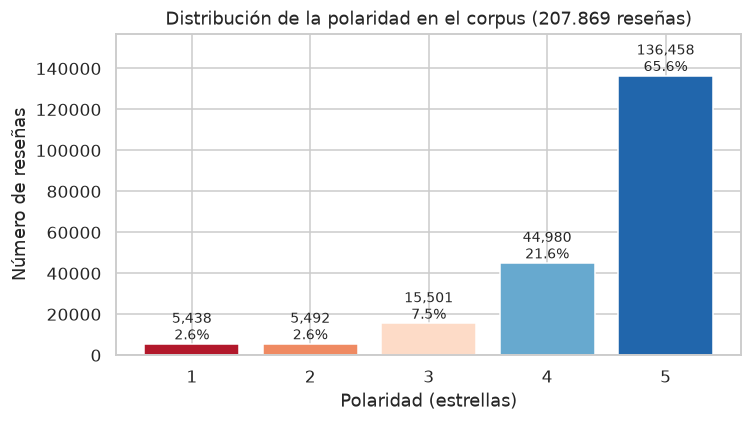

               n      %
Polarity               
1           5438   2.62
2           5492   2.64
3          15501   7.46
4          44980  21.64
5         136458  65.65

Ratio mayoritaria/minoritaria : 25.1 : 1
Polaridad media / mediana     : 4.45 / 5


In [11]:
# =========================================================================
# 3.2 · Distribución de la polaridad
# =========================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
# Paleta fija por estrella, usada en TODO el notebook (rojo = malo, azul = bueno).
PALETA_POL = {1: "#b2182b", 2: "#ef8a62", 3: "#fddbc7", 4: "#67a9cf", 5: "#2166ac"}

conteo = df["Polarity"].value_counts().sort_index()
pct = conteo / conteo.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(conteo.index, conteo.values, color=[PALETA_POL[i] for i in conteo.index])
for b, n, p in zip(barras, conteo.values, pct):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{n:,}\n{p:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Polaridad (estrellas)")
ax.set_ylabel("Número de reseñas")
ax.set_title("Distribución de la polaridad en el corpus (207.869 reseñas)")
ax.set_ylim(0, conteo.max() * 1.15)
plt.tight_layout()
plt.show()

print(pd.DataFrame({"n": conteo, "%": pct.round(2)}).to_string())
print(f"\nRatio mayoritaria/minoritaria : {conteo.max() / conteo.min():.1f} : 1")
print(f"Polaridad media / mediana     : {df['Polarity'].mean():.2f} / {df['Polarity'].median():.0f}")

In [12]:
# =========================================================================
# 3.2 · Baseline de clase mayoritaria — de aquí sale la métrica principal
# =========================================================================
from sklearn.metrics import f1_score, accuracy_score

clase_mayoritaria = int(conteo.idxmax())
y_real = df["Polarity"].values
y_pred_may = np.full_like(y_real, clase_mayoritaria)

acc_may = accuracy_score(y_real, y_pred_may)
f1_may = f1_score(y_real, y_pred_may, average="macro", labels=[1, 2, 3, 4, 5], zero_division=0)
f1_por_clase = f1_score(y_real, y_pred_may, average=None, labels=[1, 2, 3, 4, 5], zero_division=0)

print(f"Baseline = predecir SIEMPRE {clase_mayoritaria}★ (sin leer el texto)")
print(f"  accuracy  = {acc_may:.4f}")
print(f"  macro-F1  = {f1_may:.4f}")
print(f"  F1 por clase 1..5 = {[round(v, 3) for v in f1_por_clase]}")

# Línea de referencia para TODAS las tablas de resultados.
BASELINE = {"clase": clase_mayoritaria, "accuracy": float(acc_may), "macro_f1": float(f1_may)}

Baseline = predecir SIEMPRE 5★ (sin leer el texto)
  accuracy  = 0.6565
  macro-F1  = 0.1585
  F1 por clase 1..5 = [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.793)]


La siguiente celda traduce ese desbalance en tres cosas concretas: cuánto pesará cada clase
al entrenar, si reformular la tarea ayudaría, y con cuántos ejemplos reales contaremos para
las clases poco frecuentes.

In [13]:
# =========================================================================
# 3.2 (extra) · Qué implica el desbalance para el modelado
# =========================================================================
# a) Pesos de clase para la pérdida (inverso de la frecuencia, normalizado a media 1)
frec = conteo / conteo.sum()
w = (1 / frec) / (1 / frec).sum() * len(conteo)
print("class_weight (1..5):", {e: round(v, 2) for e, v in zip([1, 2, 3, 4, 5], w)})
print(f"  -> un error en 1★ pesará ~{w[1] / w[5]:.0f}x más que uno en 5★\n")

# b) ¿Se escapa del desbalance reformulando la tarea?
c3 = pd.Series(np.select([df["Polarity"] <= 2, df["Polarity"] == 3],
                         ["neg (1-2)", "neu (3)"], "pos (4-5)")).value_counts(normalize=True) * 100
c2 = pd.Series(np.where(df["Polarity"] >= 4, "pos (4-5)", "no-pos (1-3)")).value_counts(normalize=True) * 100
print("Colapsando a 3 clases (%):\n", c3.round(1).to_string())
print("\nColapsando a binario (%):\n", c2.round(1).to_string())

# c) Ejemplos de entrenamiento por clase tras la submuestra estratificada de 40k (split 80%)
proj = (frec * CFG["submuestra"] * 0.8).round().astype(int)
print(f"\nEjemplos de train por clase con submuestra de {CFG['submuestra']:,}:")
print({e: int(v) for e, v in zip([1, 2, 3, 4, 5], proj)})

# d) MAE del baseline mayoritario (para completar su fila en las tablas de resultados)
mae_may = float(np.abs(y_real - clase_mayoritaria).mean())
BASELINE["mae"] = mae_may
print(f"\nMAE del baseline 'siempre 5★': {mae_may:.3f} estrellas")

class_weight (1..5): {1: 2.0, 2: 1.98, 3: 0.7, 4: 0.24, 5: 0.08}
  -> un error en 1★ pesará ~25x más que uno en 5★



Colapsando a 3 clases (%):
 pos (4-5)    87.3
neu (3)       7.5
neg (1-2)     5.3

Colapsando a binario (%):
 pos (4-5)       87.3
no-pos (1-3)    12.7

Ejemplos de train por clase con submuestra de 40,000:
{1: 837, 2: 845, 3: 2386, 4: 6924, 5: 21007}

MAE del baseline 'siempre 5★': 0.549 estrellas


Dos de cada tres reseñas tienen 5 estrellas y solo cinco de cada cien tienen 1 o 2. Este sesgo hacia lo positivo es habitual en sitios de reseñas, así que no es un error a corregir sino una característica del problema.

La consecuencia práctica es que el accuracy (porcentaje de aciertos) deja de servir: un modelo que responda siempre "5 estrellas", sin leer el texto, acierta el 65,7 % de las
veces. Por eso medimos el éxito con el macro-F1, que evalúa la calidad clase por clase y luego promedia; ese mismo modelo perezoso saca un macro-F1 de 0,16, porque falla por
completo en cuatro de las cinco clases. Todo el notebook usa macro-F1 como criterio, y el accuracy solo se muestra al lado de este baseline como referencia.

Para que los modelos no ignoren las clases raras, al entrenar daremos a cada clase un peso inverso a su frecuencia, es decir, un error en una reseña de 1★ pesará unas 25 veces más que uno en
una de 5★.

Aun así el problema no desaparece: agrupando en positivo/neutro/negativo el corpus sigue siendo 87 % positivo, y al reducirlo a 40.000 reseñas para que todo corra en tiempo razonable quedarán apenas ~840 ejemplos de 1★ y ~845 de 2★ para entrenar. Es
suficiente para que el macro-F1 sea informativo, pero poco para conclusiones finas sobre esas dos clases; lo consideraremos en las limitaciones.

### 3.3 Tipo de establecimiento, región y pueblo

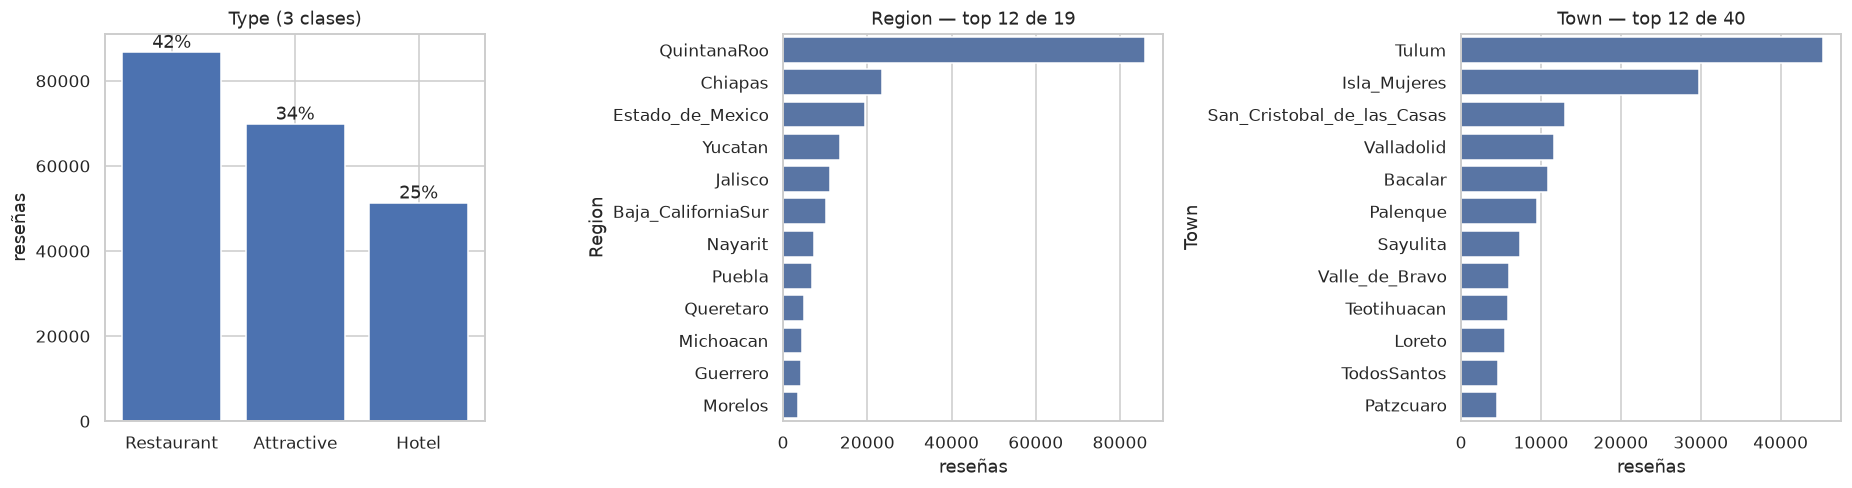

Type (%):
Type
Restaurant    41.7
Attractive    33.6
Hotel         24.7

Concentración geográfica:
  Quintana Roo         : 41.4%
  top 3 regiones       : 62.0%
  Tulum + Isla Mujeres : 36.2%

Regiones completas (n y %):
                        n      %
Region                          
QuintanaRoo         85985  41.36
Chiapas             23427  11.27
Estado_de_Mexico    19437   9.35
Yucatan             13621   6.55
Jalisco             11167   5.37
Baja_CaliforniaSur  10124   4.87
Nayarit              7337   3.53
Puebla               6830   3.29
Queretaro            4879   2.35
Michoacan            4453   2.14
Guerrero             4201   2.02
Morelos              3445   1.66
Veracruz             3335   1.60
San_Luis_Potosi      2217   1.07
Chihuahua            1786   0.86
Coahuila             1741   0.84
Hidalgo              1509   0.73
Oaxaca               1466   0.71
Guanajuato            909   0.44


In [14]:
# =========================================================================
# 3.3 · Tipo de establecimiento, región y pueblo
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

vc_type = df["Type"].value_counts()
axes[0].bar(vc_type.index, vc_type.values, color="#4c72b0")
for i, v in enumerate(vc_type.values):
    axes[0].text(i, v, f"{v / len(df) * 100:.0f}%", ha="center", va="bottom")
axes[0].set_title("Type (3 clases)"); axes[0].set_ylabel("reseñas")

vc_reg = df["Region"].value_counts()
sns.barplot(x=vc_reg.head(12).values, y=vc_reg.head(12).index, ax=axes[1], color="#4c72b0")
axes[1].set_title(f"Region — top 12 de {df['Region'].nunique()}"); axes[1].set_xlabel("reseñas")

vc_town = df["Town"].value_counts()
sns.barplot(x=vc_town.head(12).values, y=vc_town.head(12).index, ax=axes[2], color="#4c72b0")
axes[2].set_title(f"Town — top 12 de {df['Town'].nunique()}"); axes[2].set_xlabel("reseñas")

plt.tight_layout(); plt.show()

print("Type (%):")
print((vc_type / len(df) * 100).round(1).to_string())
print("\nConcentración geográfica:")
print(f"  Quintana Roo         : {vc_reg.iloc[0] / len(df) * 100:.1f}%")
print(f"  top 3 regiones       : {vc_reg.head(3).sum() / len(df) * 100:.1f}%")
print(f"  Tulum + Isla Mujeres : {vc_town.head(2).sum() / len(df) * 100:.1f}%")
print("\nRegiones completas (n y %):")
print(pd.DataFrame({"n": vc_reg, "%": (vc_reg / len(df) * 100).round(2)}).to_string())

El tipo de establecimiento está bastante repartido: 41.7 % restaurantes, 33.6 % atracciones (museos, playas, zonas arqueológicas) y 24.7 % hoteles. Es lo contrario al caso de la polaridad. Por eso, nos puede convenir usar `Type` como tarea de control: si un mismo modelo clasifica bien
el tipo pero mal las estrellas, la dificultad está en la tarea de polaridad, no en el modelo.

La geografía, en cambio, está muy concentrada. Quintana Roo (Cancún, Tulum, Isla Mujeres, Bacalar) reúne el 41 % de las reseñas, las tres regiones más grandes suman el 62 %, y solo
Tulum e Isla Mujeres ya son el 36 %. De las 19 regiones, muchas aportan menos del 1 %.

Aqui hay un riesgo para el modelo, si entrenamos y evaluamos mezclando al azar, el modelo ve durante el entrenamiento reseñas de los mismos hoteles y playas que luego tiene que calificar, y podría aprender a reconocer el destino (nombres propios, topónimos) en lugar del sentimiento.

In [15]:
# (opcional) polaridad media por tipo y por región — anticipo de 3.6
print("Polaridad media por Type:")
print(df.groupby("Type")["Polarity"].mean().round(2).to_string())
print("\nPolaridad media — regiones del held-out del Split B vs. resto:")
ho = ["Chiapas", "Baja_CaliforniaSur", "Queretaro"]
print(f"  held-out : {df[df.Region.isin(ho)]['Polarity'].mean():.2f}")
print(f"  resto    : {df[~df.Region.isin(ho)]['Polarity'].mean():.2f}")

Polaridad media por Type:
Type
Attractive    4.52
Hotel         4.32
Restaurant    4.47

Polaridad media — regiones del held-out del Split B vs. resto:
  held-out : 4.44
  resto    : 4.45


Los hoteles reciben calificaciones algo más bajas que atracciones y restaurantes (4,32
frente a 4,52 y 4,47), aunque la diferencia es pequeña y todas las medias siguen muy altas.
Y las tres regiones que podríamos dejar fuera para una prueba de generalización tienen una
polaridad media (4,44) casi idéntica a la del resto (4,45): esa eventual partición no
arrancaría sesgada por el lado de las etiquetas. Queda como observación.

### 3.4 Longitud de las reseñas → de dónde sale `MAX_LEN`

Los notebooks guía fijan la longitud de secuencia en 256 o 512 tokens sin justificarlo.
Aquí la derivamos de la distribución real: `MAX_LEN` será el percentil 95 en tokens, y
reportaremos qué fracción de reseñas queda truncada.

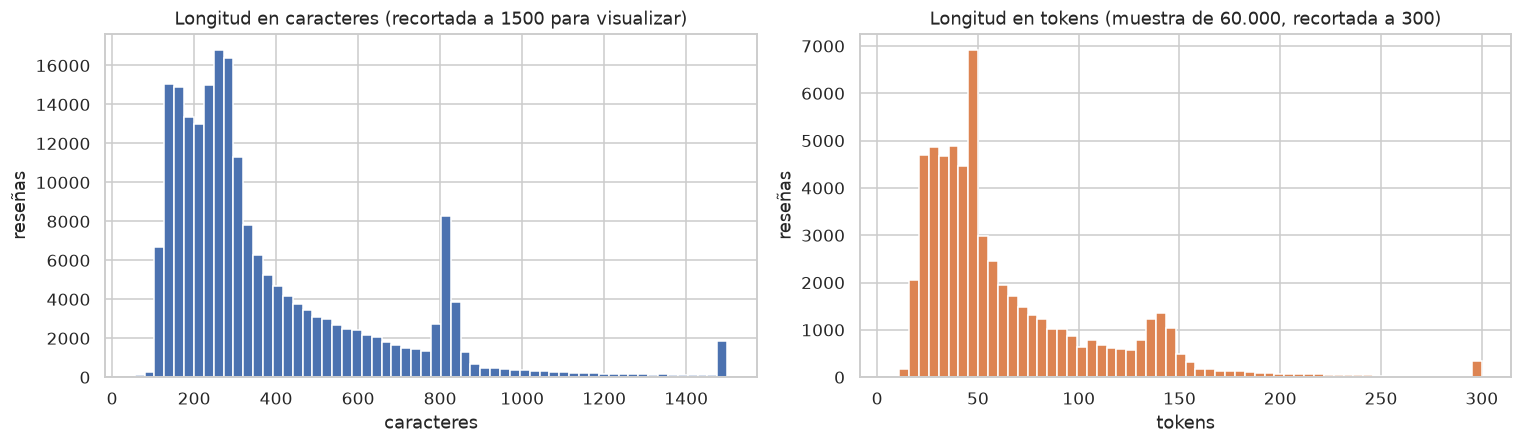

 percentil  caracteres  tokens
        50         284      48
        75         472      81
        90         803     136
        95         839     148
        99        1424     244

Mediana de tokens : 48
MAX_LEN (percentil 95 en tokens, redondeado a decena) = 150
Con ese límite se trunca el 4.4% de las reseñas (solo la cola larga).


In [16]:
# =========================================================================
# 3.4 · Longitud de las reseñas (caracteres y tokens) -> MAX_LEN
# =========================================================================
import re

# Tokenizador de trabajo solo para medir longitudes. El definitivo se fija en 4.1,
# pero usa el mismo criterio: minúsculas, se parte por lo que no sea letra o número,
# se conservan tildes y ñ.
_re_tok = re.compile(r"[^a-záéíóúüñ0-9]+")
def _tok(t):
    return [x for x in _re_tok.sub(" ", t.lower()).split() if x]

df["n_car"] = df["texto"].str.len()

# Contar tokens en las 207k reseñas es lento; usamos una muestra grande y reproducible.
muestra_tok = df["texto"].sample(60000, random_state=SEED).map(lambda t: len(_tok(t)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].hist(df["n_car"].clip(upper=1500), bins=60, color="#4c72b0")
axes[0].set_title("Longitud en caracteres (recortada a 1500 para visualizar)")
axes[0].set_xlabel("caracteres"); axes[0].set_ylabel("reseñas")
axes[1].hist(muestra_tok.clip(upper=300), bins=60, color="#dd8452")
axes[1].set_title("Longitud en tokens (muestra de 60.000, recortada a 300)")
axes[1].set_xlabel("tokens"); axes[1].set_ylabel("reseñas")
plt.tight_layout(); plt.show()

pcts = [50, 75, 90, 95, 99]
tabla_long = pd.DataFrame({
    "percentil": pcts,
    "caracteres": np.percentile(df["n_car"], pcts).round().astype(int),
    "tokens": np.percentile(muestra_tok, pcts).round().astype(int),
})
print(tabla_long.to_string(index=False))

MAX_LEN = int(round(np.percentile(muestra_tok, 95) / 10) * 10)
trunc = (muestra_tok > MAX_LEN).mean()
print(f"\nMediana de tokens : {int(muestra_tok.median())}")
print(f"MAX_LEN (percentil 95 en tokens, redondeado a decena) = {MAX_LEN}")
print(f"Con ese límite se trunca el {trunc * 100:.1f}% de las reseñas (solo la cola larga).")

La mayoría de las reseñas son cortas: la mitad tiene 48 palabras o menos y el 90 % cabe en 136. Pero hay una cola larga que llega a más de 240. Fijamos el límite de longitud (`MAX_LEN`) en 150 palabras, que es el percentil 95: con eso solo se recorta el 4,4 % de las reseñas, y siempre por el final, que suele ser la parte menos informativa.

En los histogramas hay un pico alrededor de las 140 palabras (unos 800 caracteres) que parece un corte fijo del proceso de descarga de las reseñas, no algo propio del lenguaje. El pico del extremo derecho de cada gráfica es solo el efecto de amontonar ahí todo lo que se sale del rango dibujado; los valores reales están en la tabla de percentiles.

### 3.5 Léxico distintivo por polaridad

Las frecuencias crudas están dominadas por palabras funcionales y no distinguen nada. Usamos
**log-odds ratio con prior de Dirichlet**, que mide qué tan sobrerrepresentado está un
término en una clase respecto al resto del corpus y es robusto ante términos poco frecuentes.

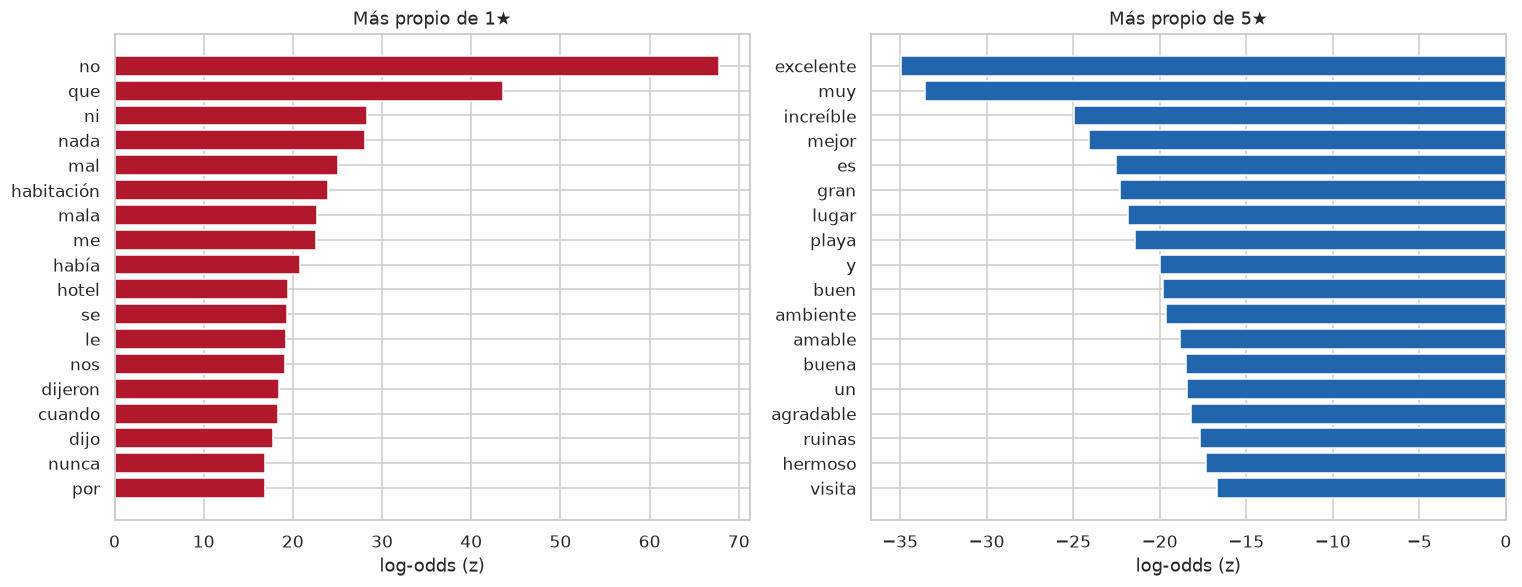

LEXICO[1] (1★): ['no', 'que', 'ni', 'nada', 'mal', 'habitación', 'mala', 'me', 'había', 'hotel', 'se', 'le', 'nos', 'dijeron', 'cuando', 'dijo', 'nunca', 'por']
LEXICO[5] (5★): ['excelente', 'muy', 'increíble', 'mejor', 'es', 'gran', 'lugar', 'playa', 'y', 'buen', 'ambiente', 'amable', 'buena', 'un', 'agradable', 'ruinas', 'hermoso', 'visita']


In [17]:
# =========================================================================
# 3.5 · Léxico distintivo: 1★ frente a 5★ (log-odds con prior de Dirichlet)
# =========================================================================
from collections import Counter

def log_odds(textos_a, textos_b, alpha=0.01, top=18, min_freq=10):
    """z-score de log-odds (Monroe et al. 2008): qué términos distinguen A de B."""
    ca, cb = Counter(), Counter()
    for t in textos_a: ca.update(_tok(t))
    for t in textos_b: cb.update(_tok(t))
    vocab = set(ca) | set(cb)
    na, nb, a0 = sum(ca.values()), sum(cb.values()), alpha * len(vocab)
    z = {}
    for w in vocab:
        if ca[w] + cb[w] < min_freq:
            continue
        la = np.log((ca[w] + alpha) / (na + a0 - ca[w] - alpha))
        lb = np.log((cb[w] + alpha) / (nb + a0 - cb[w] - alpha))
        z[w] = (la - lb) / np.sqrt(1.0 / (ca[w] + alpha) + 1.0 / (cb[w] + alpha))
    ordenado = sorted(z.items(), key=lambda kv: kv[1])
    return ordenado[-top:][::-1], ordenado[:top]   # (más de A, más de B)

txt_1 = df.loc[df["Polarity"] == 1, "texto"]
txt_5 = df.loc[df["Polarity"] == 5, "texto"].sample(len(txt_1) * 2, random_state=SEED)
mas_1, mas_5 = log_odds(txt_1, txt_5)
LEXICO = {1: [w for w, _ in mas_1], 5: [w for w, _ in mas_5]}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, datos, titulo, color in [(axes[0], mas_1, "Más propio de 1★", "#b2182b"),
                                 (axes[1], mas_5, "Más propio de 5★", "#2166ac")]:
    palabras, scores = zip(*datos)
    ax.barh(range(len(palabras)), scores, color=color)
    ax.set_yticks(range(len(palabras))); ax.set_yticklabels(palabras); ax.invert_yaxis()
    ax.set_title(titulo); ax.set_xlabel("log-odds (z)")
plt.tight_layout(); plt.show()

print("LEXICO[1] (1★):", LEXICO[1])
print("LEXICO[5] (5★):", LEXICO[5])

En las reseñas de 1★ lo que más pesa es la negación: "no", "ni", "nada", "nunca". Es un hallazgo relevante en cuanto a elegir el modelo, porque un enfoque de bolsa de palabras (que cuenta términos sin mirar el orden) no puede distinguir "no recomiendo" de "recomiendo".
También aparecen mucho "dijeron", "dijo", "nos": en las reseñas malas la gente reconstruye conversaciones con el personal. Y "habitación" y "hotel" se inclinan al lado negativo, lo que encaja con que los hoteles tenían la media de estrellas más baja.

En 5★ dominan los adjetivos de entusiasmo ("excelente", "increíble", "hermoso", "amable", "agradable") mezclados con palabras de lugar ("playa", "ruinas", "lugar", "visita"). Esto
último conviene tenerlo en cuenta: parte de la señal no es sentimiento puro sino relacionado al tema (las atracciones reciben mejores calificaciones que los hoteles), así que un modelo podría acertar en parte fijándose en de qué habla la reseña y no en cómo la valora.

Guardamos ambas listas en `LEXICO` para tenerlas como referencia.

### 3.6 Interacciones

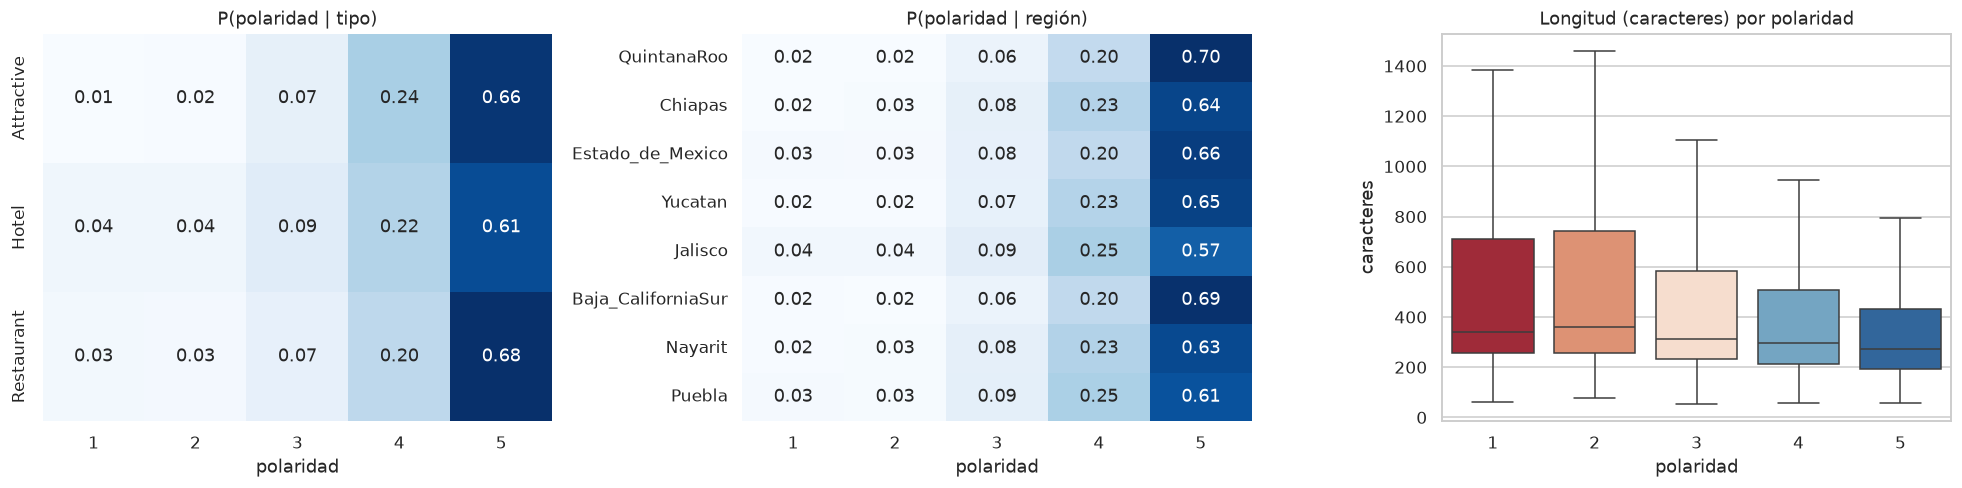

Longitud mediana (caracteres) por polaridad:
Polarity
1    339.0
2    358.0
3    313.0
4    295.0
5    274.0

Polaridad media por región (top 8), de menor a mayor:
Region
Jalisco               4.27
Puebla                4.37
Nayarit               4.42
Estado_de_Mexico      4.43
Chiapas               4.45
Yucatan               4.46
Baja_CaliforniaSur    4.52
QuintanaRoo           4.53


In [18]:
# =========================================================================
# 3.6 · Interacciones: polaridad × tipo, × región, × longitud
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

# 1) P(polaridad | tipo)
ct = pd.crosstab(df["Type"], df["Polarity"], normalize="index")
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("P(polaridad | tipo)"); axes[0].set_xlabel("polaridad"); axes[0].set_ylabel("")

# 2) P(polaridad | región) para las 8 regiones con más reseñas
top8 = df["Region"].value_counts().head(8).index
cr = pd.crosstab(df.loc[df["Region"].isin(top8), "Region"], df["Polarity"], normalize="index")
cr = cr.loc[top8]  # ordenadas por volumen
sns.heatmap(cr, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("P(polaridad | región)"); axes[1].set_xlabel("polaridad"); axes[1].set_ylabel("")

# 3) longitud (caracteres) por polaridad
sns.boxplot(data=df, x="Polarity", y="n_car", hue="Polarity", legend=False,
            palette=PALETA_POL, showfliers=False, ax=axes[2])
axes[2].set_title("Longitud (caracteres) por polaridad")
axes[2].set_xlabel("polaridad"); axes[2].set_ylabel("caracteres")

plt.tight_layout(); plt.show()

print("Longitud mediana (caracteres) por polaridad:")
print(df.groupby("Polarity")["n_car"].median().to_string())
print("\nPolaridad media por región (top 8), de menor a mayor:")
print(df[df["Region"].isin(top8)].groupby("Region")["Polarity"].mean().round(2).sort_values().to_string())

El sesgo positivo es bastante parejo. Por tipo, los hoteles concentran algo más de reseñas negativas (4 % de 1★ y 4 % de 2★, frente al 1–2 % de las atracciones) y algo menos de 5★, aunque la diferencia es moderada.

Por región, la proporción de 5★ va del 57 % (Jalisco) al 70 % (Quintana Roo), y las tres regiones que podríamos apartar para una prueba de generalización (Chiapas, Baja California Sur, Querétaro) caen dentro de ese rango: apartarlas no cambiaría de forma brusca la mezcla de etiquetas.

La longitud sí se relaciona con la polaridad: las reseñas negativas son más largas (mediana de ~340–360 caracteres en 1★ y 2★, frente a ~275 en 5★).
Esto tiene sentido, quien se queja justifica el enojo con detalle, mientras que un "todo excelente" se despacha en una frase.

### 3.7 Cobertura del vocabulario frente a los embeddings preentrenados

El modelo 3 inicializará sus embeddings con vectores de spaCy entrenados sobre español
general. Antes de hacerlo, medimos cuánto de nuestro vocabulario turístico y regional está
efectivamente cubierto.

In [19]:
# =========================================================================
# 3.7 · Cobertura del vocabulario en los vectores de spaCy (es_core_news_lg)
# =========================================================================
import spacy

nlp_vec = spacy.load("es_core_news_lg")
print("Vectores en es_core_news_lg:", nlp_vec.vocab.vectors.shape, "(nº de palabras × dimensiones)")

# Vocabulario del corpus (muestra de 50.000 reseñas para que sea rápido)
cont_vocab = Counter()
for t in df["texto"].sample(50000, random_state=SEED):
    cont_vocab.update(_tok(t))

tipos = list(cont_vocab)
con_vector = [w for w in tipos if nlp_vec.vocab[w].has_vector]
cob_tipos = len(con_vector) / len(tipos)
cob_tokens = sum(cont_vocab[w] for w in con_vector) / sum(cont_vocab.values())

oov = [(w, n) for w, n in cont_vocab.most_common() if not nlp_vec.vocab[w].has_vector][:25]

print(f"\nPalabras distintas en el corpus (muestra): {len(tipos):,}")
print(f"Cobertura por TIPOS  (palabras distintas con vector): {cob_tipos * 100:.1f}%")
print(f"Cobertura por TOKENS (apariciones cubiertas)        : {cob_tokens * 100:.1f}%")
print("\nPalabras frecuentes SIN vector (OOV):")
for w, n in oov:
    print(f"  {w:22s} {n}")

Vectores en es_core_news_lg: (500000, 300) (nº de palabras × dimensiones)



Palabras distintas en el corpus (muestra): 56,301
Cobertura por TIPOS  (palabras distintas con vector): 74.4%
Cobertura por TOKENS (apariciones cubiertas)        : 99.1%

Palabras frecuentes SIN vector (OOV):
  bacalar                953
  sayulita               817
  taxco                  503
  chichen                415
  ajijic                 309
  tlaquepaque            304
  teotihuacan            276
  pátzcuaro              229
  izamal                 216
  patzcuaro              189
  ziggy                  173
  creel                  172
  tequisquiapan          144
  rolandi                143
  tepoztlán              121
  nautibeach             113
  mazunte                109
  tepozteco              105
  covid                  103
  teotihuacán            102
  malinalco              98
  qubano                 98
  atlixco                97
  mayan                  95
  xilitla                89


Casi todas las palabras que aparecen en las reseñas (99,1 % de las apariciones) tienen vector preentrenado. La cobertura baja al 74 % si contamos palabras distintas, pero lo que
falta son casi en su totalidad nombres propios: destinos (Bacalar, Sayulita, Taxco, Chichén,
Teotihuacán) y nombres de hoteles y restaurantes (Ziggy, Rolandi, Nautibeach). Vocabulario
de sentimiento sin cubrir prácticamente no hay.

Esto tiene dos lecturas. Partir de vectores preentrenados es una buena apuesta, porque el modelo no tiene que aprender desde cero qué significan "excelente" o "pésimo". Y como los nombres de lugar no tienen vector, un modelo que los use tal cual no puede apoyarse en el destino para adivinar la nota; en cambio, si dejamos que ajuste los vectores durante el entrenamiento, podría construir representaciones para esos nombres y usarlas como atajo.

Por eso conviene probar las dos variantes, vectores congelados y vectores ajustados, y comparar.
También se nota algo de ruido ortográfico: "pátzcuaro" y "patzcuaro", "teotihuacán" y "teotihuacan", cuentan como palabras distintas por la tilde.

In [20]:
# =========================================================================
# 3.7b · Tres cifras para cerrar el diagnóstico
# =========================================================================
# (1) ¿Por qué un vocabulario de 30.000? Cobertura de apariciones según el corte.
cont_full = Counter()
for t in df["texto"].sample(80000, random_state=SEED):
    cont_full.update(_tok(t))
total = sum(cont_full.values())
print("Cobertura de apariciones según el tamaño de vocabulario:")
for k in (10000, 20000, 30000, 50000):
    cub = sum(n for _, n in cont_full.most_common(k))
    print(f"  vocab {k:>6,} -> {cub / total * 100:.2f}%")
print(f"  (palabras distintas en la muestra: {len(cont_full):,})")

# (2) Ruido de etiqueta: texto que contradice las estrellas.
neg_fuerte = {"pésimo", "pesimo", "horrible", "terrible", "asqueroso", "sucio", "estafa",
              "engaño", "robo", "nunca", "jamás", "malísimo", "peor"}
pos_fuerte = {"excelente", "maravilloso", "hermoso", "increíble", "perfecto", "espectacular",
              "encantó", "encanto", "recomiendo"}
def contiene(texto, palabras):
    return len(set(_tok(texto)) & palabras) > 0

r5 = df.loc[df["Polarity"] == 5, "texto"].map(lambda t: contiene(t, neg_fuerte)).mean()
r1 = df.loc[df["Polarity"] == 1, "texto"].map(lambda t: contiene(t, pos_fuerte)).mean()
print(f"\nReseñas de 5★ con vocabulario muy negativo en el texto: {r5 * 100:.1f}%")
print(f"Reseñas de 1★ con vocabulario muy positivo en el texto: {r1 * 100:.1f}%")

# (3) Densidad de negación por polaridad (negaciones por cada 100 palabras).
neg_tok = {"no", "ni", "nada", "nunca", "tampoco", "jamás", "sin"}
def dens_neg(texto):
    toks = _tok(texto)
    return sum(w in neg_tok for w in toks) / max(len(toks), 1) * 100
print("\nNegaciones por cada 100 palabras, según la polaridad:")
for p in (1, 2, 3, 4, 5):
    s = df.loc[df["Polarity"] == p, "texto"].sample(
        min(5000, int((df["Polarity"] == p).sum())), random_state=SEED)
    print(f"  {p}★: {s.map(dens_neg).mean():.2f}")

Cobertura de apariciones según el tamaño de vocabulario:
  vocab 10,000 -> 96.73%
  vocab 20,000 -> 98.47%


  vocab 30,000 -> 99.08%
  vocab 50,000 -> 99.59%
  (palabras distintas en la muestra: 71,266)



Reseñas de 5★ con vocabulario muy negativo en el texto: 3.3%
Reseñas de 1★ con vocabulario muy positivo en el texto: 15.3%

Negaciones por cada 100 palabras, según la polaridad:


  1★: 3.75


  2★: 3.47


  3★: 2.72
  4★: 1.39


  5★: 1.11


### 3.8 Síntesis: del hallazgo a la decisión


| Hallazgo del EDA | Decisión que induce |
|---|---|
| El corpus trae mojibake y colas "...Más" de TripAdvisor, pero cero reseñas vacías y solo 182 duplicados exactos. | Se corrige el texto (`ftfy` + recorte) y se eliminan los duplicados; nada más. Corpus de trabajo: 207.869 reseñas. |
| El 66 % de las reseñas son 5★; predecir siempre "5" da 65,7 % de accuracy pero 0,16 de macro-F1. | La métrica principal es **macro-F1**. El accuracy solo se reporta junto a este baseline. |
| Las clases 1★ y 2★ juntas son el 5 %; tras reducir a 40.000 reseñas quedan ~840 ejemplos de cada una. | Se pondera cada clase por el inverso de su frecuencia al entrenar, y se asume desde ya que las métricas de 1★ y 2★ serán ruidosas (limitación). |
| Longitudes muy asimétricas: mediana 48 palabras, percentil 95 = 148. | **`MAX_LEN` = 150 palabras** (percentil 95); trunca solo el 4 % de las reseñas. |
| En 1★ domina la negación: 3,75 por cada 100 palabras, frente a 1,11 en 5★. | Una bolsa de palabras no distingue "no recomiendo" de "recomiendo": se justifica probar modelos que miran el orden (LSTM) y en ambos sentidos (bidireccional). |
| El 99 % de las apariciones tiene vector preentrenado; lo que falta son nombres de destinos y de hoteles. | Se inicializan los embeddings con los de spaCy y se prueban **congelados y ajustados**, porque ajustar podría reintroducir el destino como atajo. |
| Quintana Roo es el 41 % del corpus; con partición aleatoria el modelo ve en entrenamiento los mismos destinos que evalúa. | Se prueba además una **partición geográfica** (Chiapas, Baja California Sur y Querétaro fuera del entrenamiento) para medir generalización a destinos nuevos. |
| La escala 1–5 está ordenada: confundir 4★ con 5★ no equivale a confundir 1★ con 5★. | Además de macro-F1 se reportan **MAE y QWK**, y se prueba una formulación de regresión con umbrales. |
| `Type` está equilibrado (42/34/25) y no es ordinal. | Sirve de **tarea de control**: la misma arquitectura sobre `Type` dirá si un macro-F1 flojo en polaridad es culpa de la tarea o del modelo. |
| El 15 % de las reseñas de 1★ usan vocabulario muy positivo (y el 3 % de las de 5★, muy negativo). | Hay ruido de etiqueta y reseñas mixtas; ponen un techo al rendimiento y se analizan en la sección de errores. |

---

## 4. Preprocesamiento y protocolo experimental

Para que la comparación entre cuatro modelos signifique algo, todos deben ver exactamente
los mismos datos, la misma partición y las mismas métricas. Esta sección fija ese contrato.

### 4.1 Tokenización

Partimos del tokenizador del notebook guía y corregimos dos cosas: construimos el vocabulario
**por frecuencia** (el notebook 4 lo hace por orden de aparición, ver `docs/DECISIONS.md`
§D-002) y verificamos que la normalización preserve tildes y ñ.

In [21]:
# =========================================================================
# 4.1 · Tokenizador definitivo y construcción del vocabulario
# =========================================================================
_RE_TOKEN = re.compile(r"[^a-záéíóúüñ0-9]+")

def tokenizar(texto: str):
    """Minúsculas; se parte por todo lo que no sea letra o número; se conservan
    tildes y ñ. Mismo criterio que se usó en el EDA."""
    return [t for t in _RE_TOKEN.sub(" ", texto.lower()).split() if t]

PAD, UNK = 0, 1

def construir_vocab(textos, max_vocab):
    """Vocabulario por FRECUENCIA (most_common), con [PAD]=0 y [UNK]=1 reservados.
    El notebook 4 del curso lo construye por orden de aparición: sobre un Counter
    eso no da los tokens más frecuentes sino los que aparecieron primero."""
    cont = Counter()
    for t in textos:
        cont.update(tokenizar(t))
    vocab = {"[PAD]": PAD, "[UNK]": UNK}
    for palabra, _ in cont.most_common(max_vocab - 2):
        vocab[palabra] = len(vocab)
    return vocab

ej = df["texto"].iloc[0]
print("Reseña :", ej[:150], "...")
print("Tokens :", tokenizar(ej)[:25], "...")
print("\nEl vocabulario definitivo se construye en 4.2, solo con el texto de entrenamiento.")

Reseña : Mi Lugar Favorito!!!!. Excelente lugar para comer y pasar una buena noche!!!
El servicio es de primera y la comida exquisita!!! ...
Tokens : ['mi', 'lugar', 'favorito', 'excelente', 'lugar', 'para', 'comer', 'y', 'pasar', 'una', 'buena', 'noche', 'el', 'servicio', 'es', 'de', 'primera', 'y', 'la', 'comida', 'exquisita'] ...

El vocabulario definitivo se construye en 4.2, solo con el texto de entrenamiento.


In [22]:
# --- Cómo se convierte una reseña en entrada para el modelo: tokens -> ids -> padding ---
def codificar(texto, vocab, max_len=MAX_LEN):
    ids = [vocab.get(t, UNK) for t in tokenizar(texto)[:max_len]]
    n_real = max(len(ids), 1)                 # longitud antes del relleno
    ids += [PAD] * (max_len - len(ids))
    return ids, n_real

# Vocabulario temporal (solo para esta demostración; el real se hace en 4.2)
_vocab_demo = construir_vocab(df["texto"], CFG["max_vocab"])
_id2tok = {i: t for t, i in _vocab_demo.items()}

frase = "El hotel estaba sucio y el sargazo cubría toda la playa. No volvería."
ids, n = codificar(frase, _vocab_demo, max_len=20)
print("Texto        :", frase)
print("Tokens       :", tokenizar(frase))
print("IDs          :", ids)
print("Reconstruido :", [_id2tok[i] for i in ids])
print(f"\n{n} tokens reales; los otros {20 - n} son [PAD] (relleno para que todas las")
print("secuencias tengan el mismo largo y se puedan procesar por lotes).")
del _vocab_demo, _id2tok

Texto        : El hotel estaba sucio y el sargazo cubría toda la playa. No volvería.
Tokens       : ['el', 'hotel', 'estaba', 'sucio', 'y', 'el', 'sargazo', 'cubría', 'toda', 'la', 'playa', 'no', 'volvería']
IDs          : [5, 31, 61, 1540, 3, 5, 2041, 23470, 233, 4, 35, 14, 590, 0, 0, 0, 0, 0, 0, 0]
Reconstruido : ['el', 'hotel', 'estaba', 'sucio', 'y', 'el', 'sargazo', 'cubría', 'toda', 'la', 'playa', 'no', 'volvería', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

13 tokens reales; los otros 7 son [PAD] (relleno para que todas las
secuencias tengan el mismo largo y se puedan procesar por lotes).


El tokenizador parte el texto en palabras, pasa todo a minúsculas y elimina signos y saltos
de línea, pero conserva tildes y ñ (importante en español). Cada palabra se sustituye por un
número, que es su posición en el vocabulario; las palabras que no estén en el vocabulario se
marcan como `[UNK]`, y las secuencias más cortas que `MAX_LEN` se completan con `[PAD]` para
que todos los ejemplos tengan el mismo largo y se puedan procesar por lotes.

El vocabulario se ordena por frecuencia: las palabras más comunes ("el", "y", "la") reciben
los números más bajos y las raras ("cubría"), los más altos. En el ejemplo, las 13 palabras
reales caben de sobra en el límite de 150 y ninguna quedó fuera del vocabulario.

### 4.2 Submuestra y particiones

Entrenamos sobre 40,000 reseñas estratificadas por polaridad. **No balanceamos las clases**:
el desbalance es una propiedad del dominio que queremos estudiar, no un defecto que ocultar.

In [23]:
# =========================================================================
# 4.2 · Submuestra estratificada
# =========================================================================
from sklearn.model_selection import train_test_split

N_SUB = min(CFG["submuestra"], len(df))
sub, _ = train_test_split(df, train_size=N_SUB, random_state=SEED, stratify=df["Polarity"])
sub = sub.reset_index(drop=True)

comp = pd.DataFrame({
    "corpus (%)":     (df["Polarity"].value_counts(normalize=True).sort_index() * 100).round(2),
    "submuestra (%)": (sub["Polarity"].value_counts(normalize=True).sort_index() * 100).round(2),
    "n en submuestra": sub["Polarity"].value_counts().sort_index(),
})
print(f"Submuestra: {len(sub):,} reseñas (de {len(df):,}), estratificada por polaridad.")
print(comp.to_string())

Submuestra: 40,000 reseñas (de 207,869), estratificada por polaridad.
          corpus (%)  submuestra (%)  n en submuestra
Polarity                                             
1               2.62            2.62             1046
2               2.64            2.64             1057
3               7.46            7.46             2983
4              21.64           21.64             8655
5              65.65           65.65            26259


La submuestra de 40.000 reseñas conserva exactamente las proporciones del corpus (66 % de
5★, 2,6 % de 1★).

In [24]:
# =========================================================================
# 4.2 · Split A — aleatorio estratificado 80/10/10 (protocolo estándar)
# =========================================================================
idx = np.arange(len(sub))
y = sub["Polarity"].values

idx_tr, idx_tmp = train_test_split(idx, test_size=0.20, random_state=SEED, stratify=y)
idx_va, idx_te = train_test_split(idx_tmp, test_size=0.50, random_state=SEED, stratify=y[idx_tmp])
SPLIT_A = {"train": idx_tr, "val": idx_va, "test": idx_te}

print("Split A:")
for k, v in SPLIT_A.items():
    d = (pd.Series(y[v]).value_counts(normalize=True).sort_index() * 100).round(1)
    print(f"  {k:5s}: {len(v):>6,} reseñas  |  % por estrella: {d.tolist()}")

# Vocabulario definitivo: SOLO con el texto de entrenamiento de Split A (sin fuga)
vocab = construir_vocab(sub.iloc[SPLIT_A["train"]]["texto"], CFG["max_vocab"])
id2tok = {i: t for t, i in vocab.items()}
print(f"\nVocabulario definitivo: {len(vocab):,} tokens")

# Tasa de [UNK] y de truncamiento sobre el conjunto de test
unk = tot = trunc = 0
for t in sub.iloc[SPLIT_A["test"]]["texto"]:
    toks = tokenizar(t)
    tot += len(toks); unk += sum(w not in vocab for w in toks); trunc += len(toks) > MAX_LEN
print(f"En test -> tokens fuera del vocabulario: {unk / tot * 100:.1f}%  |  "
      f"reseñas truncadas por MAX_LEN: {trunc / len(SPLIT_A['test']) * 100:.1f}%")

Split A:
  train: 32,000 reseñas  |  % por estrella: [2.6, 2.6, 7.5, 21.6, 65.6]
  val  :  4,000 reseñas  |  % por estrella: [2.6, 2.6, 7.4, 21.6, 65.6]
  test :  4,000 reseñas  |  % por estrella: [2.6, 2.6, 7.5, 21.6, 65.6]



Vocabulario definitivo: 30,000 tokens
En test -> tokens fuera del vocabulario: 1.5%  |  reseñas truncadas por MAX_LEN: 4.2%


El Split A la divide en 80/10/10 manteniendo esas proporciones en las tres partes, así que entrenamiento, validación y prueba son comparables entre sí. El vocabulario definitivo (30.000 palabras, construido solo con el texto de entrenamiento) deja fuera apenas el 1,5 % de las palabras del test, y el límite de 150 palabras trunca el 4,2 %, es decir, perdidas pequeñas.

In [25]:
# =========================================================================
# 4.2 · Split B — geográfico (regiones fuera del entrenamiento)
# =========================================================================
REGIONES_FUERA = ["Chiapas", "Baja_CaliforniaSur", "Queretaro"]

es_fuera = sub["Region"].isin(REGIONES_FUERA).values
idx_b_test = idx[es_fuera]
idx_b_rest = idx[~es_fuera]
idx_b_tr, idx_b_va = train_test_split(idx_b_rest, test_size=0.12, random_state=SEED,
                                      stratify=y[idx_b_rest])
SPLIT_B = {"train": idx_b_tr, "val": idx_b_va, "test": idx_b_test}

print(f"Regiones fuera del entrenamiento: {REGIONES_FUERA}")
for k, v in SPLIT_B.items():
    print(f"  {k:5s}: {len(v):>6,} reseñas")

print("\nComprobación de que el test geográfico no está sesgado:")
print(f"  polaridad media : {sub.iloc[idx_b_test]['Polarity'].mean():.2f}  vs  "
      f"{sub.iloc[idx_b_rest]['Polarity'].mean():.2f}  (resto)")
print(f"  % hoteles       : {(sub.iloc[idx_b_test]['Type'] == 'Hotel').mean() * 100:.0f}%  vs  "
      f"{(sub.iloc[idx_b_rest]['Type'] == 'Hotel').mean() * 100:.0f}%  (resto)")
print(f"  % 5★            : {(sub.iloc[idx_b_test]['Polarity'] == 5).mean() * 100:.0f}%  vs  "
      f"{(sub.iloc[idx_b_rest]['Polarity'] == 5).mean() * 100:.0f}%  (resto)")

Regiones fuera del entrenamiento: ['Chiapas', 'Baja_CaliforniaSur', 'Queretaro']
  train: 28,638 reseñas
  val  :  3,906 reseñas
  test :  7,456 reseñas

Comprobación de que el test geográfico no está sesgado:
  polaridad media : 4.43  vs  4.46  (resto)


  % hoteles       : 28%  vs  24%  (resto)
  % 5★            : 64%  vs  66%  (resto)


El Split B aparta tres regiones enteras (Chiapas, Baja California Sur y Querétaro; 7.456 reseñas, el 18,5 %). La polaridad media se ve casi igual (4,43 vs 4,46) y la proporción de 5★ es casi igual (64 % vs 66 %). Tiene algo más de hoteles (28 % vs 24 %), que suelen recibir peores notas, así que si el rendimiento cae en el Split B habrá que descontar esa pequeña diferencia.

### 4.3 Métricas y baselines

Una única función de evaluación que devuelve las seis métricas, usada sin excepción por
todos los modelos del notebook. Es lo que hace que la tabla final sea comparable.

In [26]:
# =========================================================================
# 4.3 · Función de evaluación única — todos los modelos la usan sin excepción
# =========================================================================
from sklearn.metrics import (f1_score, accuracy_score, mean_absolute_error,
                             cohen_kappa_score, confusion_matrix, classification_report)

ESTRELLAS = [1, 2, 3, 4, 5]
RESULTADOS = []   # una fila por modelo
PREDS = {}        # nombre -> (y_true, y_pred) en el test de Split A, para el análisis de errores

def evaluar(y_true, y_pred, nombre, registrar=True, n_params=None, segundos=None):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    f1c = f1_score(y_true, y_pred, average=None, labels=ESTRELLAS, zero_division=0)
    fila = {
        "modelo":   nombre,
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=ESTRELLAS, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "mae":      mean_absolute_error(y_true, y_pred),
        "qwk":      cohen_kappa_score(y_true, y_pred, weights="quadratic", labels=ESTRELLAS),
        **{f"f1_{e}": v for e, v in zip(ESTRELLAS, f1c)},
        "n_params": n_params, "segundos": segundos,
    }
    if registrar:
        RESULTADOS.append(fila)
    print(f"{nombre:38s} | macro-F1 {fila['macro_f1']:.4f} | acc {fila['accuracy']:.4f} "
          f"| MAE {fila['mae']:.3f} | QWK {fila['qwk']:.4f}")
    return fila

print("evaluar() lista. Métricas que devuelve:")
print("  macro-F1 : media de la F1 de las 5 clases (métrica principal del notebook)")
print("  accuracy : % de aciertos (solo se lee junto al baseline mayoritario)")
print("  MAE      : error medio en estrellas (0.5 = se equivoca media estrella de media)")
print("  QWK      : acuerdo con la nota real penalizando más los errores grandes (1=perfecto, 0=azar)")
print("  f1_1..f1_5 : F1 de cada clase por separado")

evaluar() lista. Métricas que devuelve:
  macro-F1 : media de la F1 de las 5 clases (métrica principal del notebook)
  accuracy : % de aciertos (solo se lee junto al baseline mayoritario)
  MAE      : error medio en estrellas (0.5 = se equivoca media estrella de media)
  QWK      : acuerdo con la nota real penalizando más los errores grandes (1=perfecto, 0=azar)
  f1_1..f1_5 : F1 de cada clase por separado


In [27]:
# =========================================================================
# 4.3 · Baselines — ningún modelo es "útil" si no los supera en macro-F1
# =========================================================================
y_tr_A = sub.iloc[SPLIT_A["train"]]["Polarity"].values
y_te_A = sub.iloc[SPLIT_A["test"]]["Polarity"].values

# 1) Clase mayoritaria: predecir siempre la estrella más frecuente del entrenamiento
clase = int(pd.Series(y_tr_A).value_counts().idxmax())
evaluar(y_te_A, np.full_like(y_te_A, clase), f"Baseline · siempre {clase}★")

# 2) Azar estratificado: sortear según la distribución del entrenamiento
fijar_semilla()
p = pd.Series(y_tr_A).value_counts(normalize=True).sort_index()
y_azar = np.random.choice(p.index.values, size=len(y_te_A), p=p.values)
evaluar(y_te_A, y_azar, "Baseline · azar estratificado")

pd.DataFrame(RESULTADOS)[["modelo", "macro_f1", "accuracy", "mae", "qwk"]].round(4)

Baseline · siempre 5★                  | macro-F1 0.1585 | acc 0.6565 | MAE 0.549 | QWK 0.0000
Baseline · azar estratificado          | macro-F1 0.1931 | acc 0.4798 | MAE 0.834 | QWK 0.0045


,modelo,macro_f1,accuracy,mae,qwk
0,Baseline · siempre 5★,0.1585,0.6565,0.5495,0.0000
1,Baseline · azar estratificado,0.1931,0.4798,0.8342,0.0045


Los dos baselines dejan claro por qué hacen falta varias métricas a la vez. Predecir siempre "5★" tiene buen accuracy (0,66) pero macro-F1 de 0,16, porque cuatro clases quedan en cero.
Sortear al azar respetando las proporciones sube el macro-F1 a 0 19 (todas las clases reciben algo de acierto) pero hunde el accuracy a 0,48 y empeora el error medio a 0,83 estrellas. Y el QWK de ambos es prácticamente cero: ninguno tiene el más mínimo acuerdo real con la nota que puso el autor.

Un modelo solo cuenta como útil si supera el macro-F1 del azar (0,19) sin caer por debajo del accuracy de la clase mayoritaria (0,66), y si además consigue un QWK claramente positivo.

---

## 5. Modelo 1 - TF-IDF + Regresión Logística

Empezamos por el baseline clásico, y no por trámite: en clasificación de sentimiento
con textos de longitud media, TF-IDF con n-gramas es un rival duro. Si las redes neuronales
no lo superan, es que no están aportando nada sobre esta tarea, y eso también sería un
hallazgo.

Usamos n-gramas de 1 a 2 y `class_weight='balanced'` para que la regresión no colapse sobre
la clase mayoritaria.

In [28]:
# =========================================================================
# 5 · Modelo 1 — TF-IDF + Regresión Logística
# =========================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

txt_tr = sub.iloc[SPLIT_A["train"]]["texto"].values
txt_te = sub.iloc[SPLIT_A["test"]]["texto"].values

modelo1 = Pipeline([
    ("tfidf", TfidfVectorizer(tokenizer=tokenizar, token_pattern=None,
                              ngram_range=(1, 2), min_df=3, sublinear_tf=True,
                              max_features=60000)),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0)),
])

t0 = time.time()
modelo1.fit(txt_tr, y_tr_A)
seg1 = time.time() - t0
pred1 = modelo1.predict(txt_te)
n_feat = len(modelo1.named_steps["tfidf"].vocabulary_)
print(f"TF-IDF: {n_feat:,} features (1 y 2-gramas)  |  entrenamiento: {seg1:.1f} s")

TF-IDF: 60,000 features (1 y 2-gramas)  |  entrenamiento: 27.0 s


In [29]:
evaluar(y_te_A, pred1, "1 · TF-IDF + LogReg", n_params=n_feat, segundos=seg1)
PREDS["1 · TF-IDF + LogReg"] = (y_te_A, pred1)

print("\nF1 por clase:", {e: round(v, 3) for e, v in zip(
    ESTRELLAS, f1_score(y_te_A, pred1, average=None, labels=ESTRELLAS, zero_division=0))})

vec = modelo1.named_steps["tfidf"]; clf = modelo1.named_steps["clf"]
nombres = np.array(vec.get_feature_names_out())
print("\nTérminos que más empujan hacia cada clase:")
for i, estr in enumerate(clf.classes_):
    top = nombres[np.argsort(clf.coef_[i])[-10:][::-1]]
    print(f"  {estr}★: {', '.join(top)}")

1 · TF-IDF + LogReg                    | macro-F1 0.5235 | acc 0.6785 | MAE 0.376 | QWK 0.7261

F1 por clase: {1: np.float64(0.596), 2: np.float64(0.301), 3: np.float64(0.433), 4: np.float64(0.475), 5: np.float64(0.813)}

Términos que más empujan hacia cada clase:
  1★: pésimo, peor, horrible, pésima, pesimo, mala, no, sucio, mal, nada
  2★: no, decepción, mal, malo, mala, ni, triste, no vale, decepcionante, cobran
  3★: normal, pero, regular, mejorar, bien, pero no, buena, promedio, mantenimiento, aceptable
  4★: buen, buena, un poco, muy, excelente, agradable, bien, opción, gran, bueno
  5★: excelente, increíble, delicioso, deliciosa, maravilloso, hermoso, súper, impresionante, perfecto, el mejor


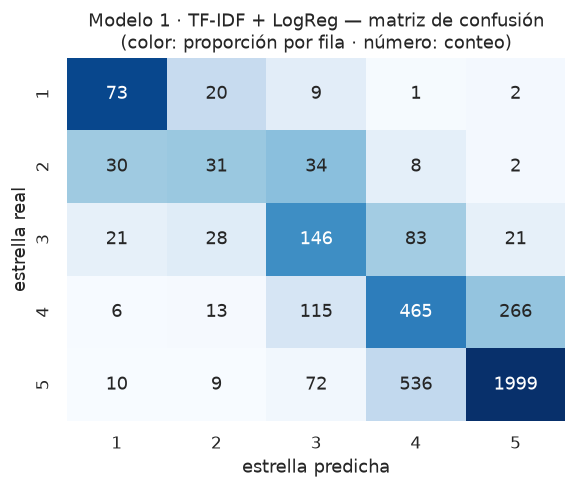

In [30]:
# Matriz de confusión como gráfica: color = proporción por fila, número = conteo
cm = confusion_matrix(y_te_A, pred1, labels=ESTRELLAS)
cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.4, 4.6))
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues", cbar=False,
            xticklabels=ESTRELLAS, yticklabels=ESTRELLAS, ax=ax)
ax.set_xlabel("estrella predicha"); ax.set_ylabel("estrella real")
ax.set_title("Modelo 1 · TF-IDF + LogReg — matriz de confusión\n"
             "(color: proporción por fila · número: conteo)")
plt.tight_layout(); plt.show()

El salto respecto a los baselines es grande: macro-F1 pasa de 0,19 a 0,53, el error medio
baja a 0,38 estrellas y el QWK sube a 0,73, lo que significa que el modelo sí coincide con la
valoración del autor y no solo adivina. Y lo consigue una técnica clásica en 38 segundos.

Clase por clase se ve dónde cuesta. 5★ va muy bien (F1 0,81) y 1★ razonablemente bien (0,60): la negación y palabras como "pésimo" o "sucio" son señales claras.

2★ se queda en 0,31, esto lo puede explicar, la matriz de confusión, ya que se ve que casi ninguna reseña de 2★ se predice como 2★, se reparten entre 1★ y 3★, sus vecinas. Es una clase pequeña y sin vocabulario propio, comparte "malo/decepción" con 1★. La otra zona de confusión es la frontera 4★–5★, donde cientos de reseñas se intercambian: la diferencia entre "muy bueno" y "excelente" depende del autor.

Los términos con más peso confirman el análisis exploratorio: 1★ se apoya en "pésimo", "horrible", "sucio", "no"; 5★ en "excelente", "delicioso", "maravilloso". Y 3★ aprende un patrón propio, "normal", "regular", "promedio", "pero", que es justo como suena una reseña tibia.

---

## 6. Modelo 2 - LSTM entrenada desde cero

Réplica de la arquitectura del notebook 3 del curso (`Embedding → LSTM → Linear`)
pero sobre nuestros datos. Es el punto de comparación directo con el material de clase: los
embeddings se aprenden desde cero, sin conocimiento lingüístico previo, solo a partir de las
40,000 reseñas de entrenamiento.

La pregunta es si añadir orden secuencial y representaciones densas compensa perder la
robustez de TF-IDF cuando los datos son limitados.

In [31]:
# =========================================================================
# 6 · Infraestructura común de los modelos neuronales (PyTorch)
# =========================================================================
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Codificamos toda la submuestra una sola vez, con el vocabulario definitivo.
def codificar_todo(textos, vocab, max_len=MAX_LEN):
    X = np.zeros((len(textos), max_len), dtype=np.int64)
    L = np.zeros(len(textos), dtype=np.int64)
    for i, t in enumerate(textos):
        ids = [vocab.get(w, UNK) for w in tokenizar(t)[:max_len]]
        L[i] = max(len(ids), 1)
        X[i, :len(ids)] = ids
    return torch.from_numpy(X), torch.from_numpy(L)

XIDS, XLEN = codificar_todo(sub["texto"].values, vocab)
print("Tensores del corpus:", tuple(XIDS.shape), "| longitudes:", tuple(XLEN.shape))

# Etiquetas de polaridad como índices 0..4 (las redes usan clases desde 0)
POL2IDX = {p: p - 1 for p in ESTRELLAS}
IDX2POL = {i: p for p, i in POL2IDX.items()}
y_idx = sub["Polarity"].map(POL2IDX).values.astype(np.int64)

class ResenasDS(Dataset):
    def __init__(self, indices, etiquetas, regresion=False):
        self.ids = XIDS[indices]
        self.len = XLEN[indices]
        self.y = torch.tensor(np.asarray(etiquetas)[indices],
                              dtype=torch.float32 if regresion else torch.long)
    def __len__(self):  return len(self.y)
    def __getitem__(self, i):  return self.ids[i], self.len[i], self.y[i]

def hacer_loaders(split, etiquetas, regresion=False, batch=None):
    b = batch or CFG["batch"]
    mk = lambda parte: DataLoader(ResenasDS(split[parte], etiquetas, regresion),
                                  batch_size=b, shuffle=(parte == "train"), generator=G)
    return mk("train"), mk("val"), mk("test")

def pesos_de_clase(indices, n_clases=5):
    c = np.bincount(y_idx[indices], minlength=n_clases).astype(float)
    w = c.sum() / (n_clases * np.maximum(c, 1))
    return torch.tensor(w, dtype=torch.float32, device=DISPOSITIVO)

print("ResenasDS, hacer_loaders(), pesos_de_clase() listos.")

Tensores del corpus: (40000, 150) | longitudes: (40000,)
ResenasDS, hacer_loaders(), pesos_de_clase() listos.


In [32]:
# --- Predicción y entrenamiento genéricos (los usan todos los modelos neuronales) ---
@torch.no_grad()
def predecir(modelo, loader, regresion=False, umbrales=None, devolver_pesos=False):
    modelo.eval()
    reales, preds, pesos = [], [], []
    for ids, lon, yb in loader:
        ids, lon = ids.to(DISPOSITIVO), lon.to(DISPOSITIVO)
        out = modelo(ids, lon)
        if isinstance(out, tuple):
            out, w = out
            if devolver_pesos: pesos.append(w.cpu())
        if regresion:
            v = out.squeeze(-1).cpu().numpy()
            p = np.clip(np.round(v), 0, 4) if umbrales is None else np.digitize(v, umbrales)
            preds.append(p.astype(int))
        else:
            preds.append(out.argmax(1).cpu().numpy())
        reales.append(yb.numpy().astype(int))
    yt = np.array([IDX2POL[int(i)] for i in np.concatenate(reales)])
    yp = np.array([IDX2POL[int(min(max(i, 0), 4))] for i in np.concatenate(preds)])
    return (yt, yp, torch.cat(pesos)) if devolver_pesos else (yt, yp)

def entrenar(modelo, dl_tr, dl_va, *, epocas=None, lr=None, pesos=None,
             regresion=False, nombre="modelo"):
    modelo = modelo.to(DISPOSITIVO)
    epocas = epocas or CFG["epocas"]; lr = lr or CFG["lr"]
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    crit = nn.MSELoss() if regresion else nn.CrossEntropyLoss(weight=pesos)
    mejor, mejor_estado, sin_mejora, hist = -1e9, None, 0, []
    t0 = time.time()
    for ep in range(1, epocas + 1):
        modelo.train(); suma = 0.0
        for ids, lon, yb in dl_tr:
            ids, lon, yb = ids.to(DISPOSITIVO), lon.to(DISPOSITIVO), yb.to(DISPOSITIVO)
            opt.zero_grad()
            out = modelo(ids, lon)
            if isinstance(out, tuple): out = out[0]
            loss = crit(out.squeeze(-1), yb) if regresion else crit(out, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 5.0)
            opt.step(); suma += loss.item() * len(yb)
        yt, yp = predecir(modelo, dl_va, regresion=regresion)
        vf1 = f1_score(yt, yp, average="macro", labels=ESTRELLAS, zero_division=0)
        vmae = mean_absolute_error(yt, yp)
        hist.append({"epoca": ep, "loss": suma / len(dl_tr.dataset), "val_f1": vf1, "val_mae": vmae})
        criterio = -vmae if regresion else vf1
        marca = ""
        if criterio > mejor:
            mejor, sin_mejora = criterio, 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
            marca = " *"
        else:
            sin_mejora += 1
        print(f"  época {ep:2d} | loss {hist[-1]['loss']:.4f} | val macro-F1 {vf1:.4f} | val MAE {vmae:.3f}{marca}")
        if sin_mejora >= CFG["paciencia"]:
            print(f"  parada temprana (sin mejora en {CFG['paciencia']} épocas)"); break
    modelo.load_state_dict(mejor_estado)
    n_par = sum(p.numel() for p in modelo.parameters())
    return modelo, hist, time.time() - t0, n_par

print("predecir() y entrenar() listos.")

predecir() y entrenar() listos.


In [33]:
# =========================================================================
# 6 · Modelo 2 — LSTM entrenada desde cero
# =========================================================================
class ClasificadorLSTM(nn.Module):
    """Embedding entrenable -> LSTM unidireccional -> lineal sobre el último estado."""
    def __init__(self, tam_vocab, n_clases=5, emb_dim=None, hidden=None):
        super().__init__()
        emb_dim = emb_dim or CFG["emb_dim"]
        hidden = hidden or CFG["hidden"]
        self.embedding = nn.Embedding(tam_vocab, emb_dim, padding_idx=PAD)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.salida = nn.Linear(hidden, n_clases)

    def forward(self, ids, longitudes=None):      # ignora longitudes, como el notebook guía
        emb = self.embedding(ids)
        _, (h, _) = self.lstm(emb)
        return self.salida(self.dropout(h[-1]))


In [34]:
RESULTADOS[:] = [r for r in RESULTADOS if not r["modelo"].startswith("2 ·")]  # evita fila duplicada

fijar_semilla(); G.manual_seed(SEED)
dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_idx)
w_clase = pesos_de_clase(SPLIT_A["train"])
print("Pesos de clase (1★..5★):", w_clase.cpu().numpy().round(2))

lstm = ClasificadorLSTM(len(vocab))
lstm, hist_lstm, seg_lstm, par_lstm = entrenar(lstm, dl_tr, dl_va, pesos=w_clase,
                                               epocas=15, nombre="LSTM desde cero")
print(f"\nParámetros: {par_lstm:,}  |  tiempo: {seg_lstm:.0f} s")

Pesos de clase (1★..5★): [7.65 7.57 2.68 0.92 0.3 ]


  época  1 | loss 1.6151 | val macro-F1 0.1880 | val MAE 0.602 *


  época  2 | loss 1.6014 | val macro-F1 0.0471 | val MAE 2.389


  época  3 | loss 1.5715 | val macro-F1 0.1891 | val MAE 1.071 *


  época  4 | loss 1.5288 | val macro-F1 0.1563 | val MAE 1.430


...

  época 11 | loss 1.3254 | val macro-F1 0.2512 | val MAE 0.755 *


  época 12 | loss 1.2872 | val macro-F1 0.2555 | val MAE 0.654 *


  época 13 | loss 1.2623 | val macro-F1 0.2708 | val MAE 0.694 *


  época 14 | loss 1.2244 | val macro-F1 0.2813 | val MAE 0.672 *


  época 15 | loss 1.2063 | val macro-F1 0.2863 | val MAE 0.666 *

Parámetros: 3,972,741  |  tiempo: 50 s


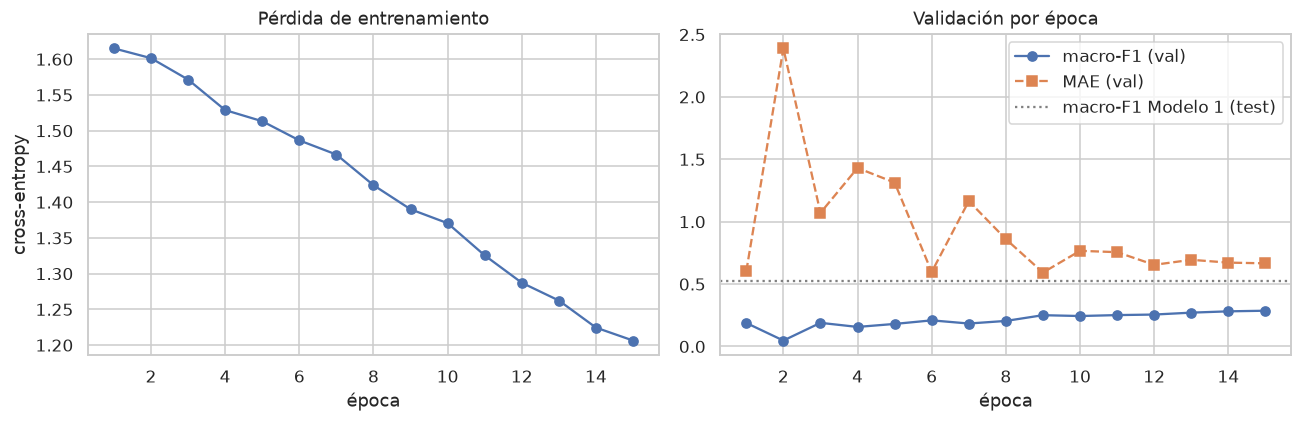

In [35]:
# Curvas de entrenamiento
h = pd.DataFrame(hist_lstm)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h["epoca"], h["loss"], "o-")
axes[0].set_title("Pérdida de entrenamiento"); axes[0].set_xlabel("época"); axes[0].set_ylabel("cross-entropy")
axes[1].plot(h["epoca"], h["val_f1"], "o-", label="macro-F1 (val)")
axes[1].plot(h["epoca"], h["val_mae"], "s--", label="MAE (val)")
axes[1].axhline(0.525, color="gray", ls=":", label="macro-F1 Modelo 1 (test)")
axes[1].set_title("Validación por época"); axes[1].set_xlabel("época"); axes[1].legend()
plt.tight_layout(); plt.show()

2 · LSTM desde cero                    | macro-F1 0.2951 | acc 0.5755 | MAE 0.651 | QWK 0.3552


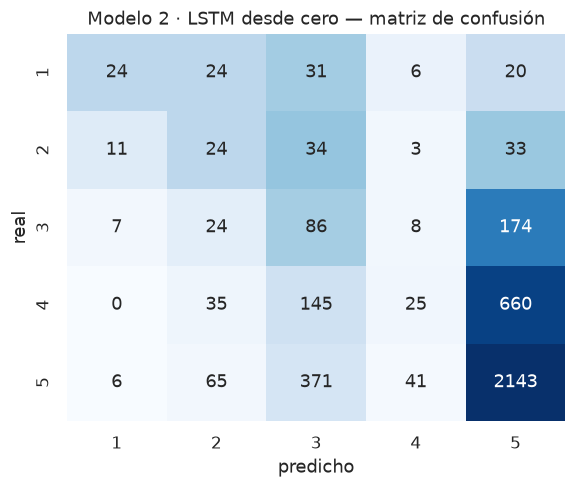

F1 por clase: {1: np.float64(0.314), 2: np.float64(0.173), 3: np.float64(0.178), 4: np.float64(0.053), 5: np.float64(0.758)}


In [36]:
yt, yp = predecir(lstm, dl_te)
evaluar(yt, yp, "2 · LSTM desde cero", n_params=par_lstm, segundos=seg_lstm)
PREDS["2 · LSTM desde cero"] = (yt, yp)

cm = confusion_matrix(yt, yp, labels=ESTRELLAS)
fig, ax = plt.subplots(figsize=(5.4, 4.6))
sns.heatmap(cm / cm.sum(1, keepdims=True), annot=cm, fmt="d", cmap="Blues", cbar=False,
            xticklabels=ESTRELLAS, yticklabels=ESTRELLAS, ax=ax)
ax.set_xlabel("predicho"); ax.set_ylabel("real")
ax.set_title("Modelo 2 · LSTM desde cero — matriz de confusión")
plt.tight_layout(); plt.show()

print("F1 por clase:", {e: round(v, 3) for e, v in zip(
    ESTRELLAS, f1_score(yt, yp, average=None, labels=ESTRELLAS, zero_division=0))})

Con 15 épocas el LSTM alcanza macro-F1 0,44, pero sigue por debajo de TF-IDF (0,53) en todas las métricas y en todas las clases. Añadir el orden de las palabras no compensó, porque el modelo tiene que aprender el significado de cada palabra desde cero con solo 32.000 reseñas (TF-IDF aprovecha directamente las estadísticas de las palabras), y lee su "resumen" de la reseña sobre una secuencia de 150 posiciones que en su mayoría son
relleno, porque la reseña típica tiene 48 palabras.

La curva de la izquierda lo confirma: la pérdida de entrenamiento sigue bajando con fuerza mientras el macro-F1 de validación se estanca cerca de 0,45. El modelo está empezando a memorizar el entrenamiento sin mejorar en datos nuevos, así que entrenar mucho más no ayuda.

Aun así, el LSTM supera con holgura a los baselines (macro-F1 0 44 frente a 0,19; QWK 0,65 frente a 0) y su error medio en estrellas (0,47) es cercano al de TF-IDF: acierta la magnitud aunque falle más en la clase exacta.

---

## 7. Modelo 3 - BiLSTM con embeddings preentrenados en español

Tres cambios sobre el modelo anterior, cada uno con su razón:

1. **Embeddings preentrenados** (`es_core_news_lg`, 300d): el modelo ya no tiene que aprender
   qué significa «excelente» a partir de 40,000 ejemplos; lo trae de un corpus mucho mayor.
2. **Bidireccionalidad**: en «no estuvo mal» la negación precede al término polar, y una LSTM
   unidireccional llega tarde a esa información.
3. **`pack_padded_sequence`**: los notebooks guía leen `hidden[-1]` sobre secuencias rellenas
   con `[PAD]`, de modo que el estado final corresponde al relleno y no al final del texto.
   Empaquetar las secuencias corrige esto (`docs/DECISIONS.md` §D-002).

Comparamos además dos variantes: embeddings **congelados** frente a **afinados**.

In [37]:
# =========================================================================
# 7 · Modelo 3 — matriz de embeddings preentrenados (spaCy es_core_news_lg)
# =========================================================================
DIM_EMB = nlp_vec.vocab.vectors.shape[1]   # 300

fijar_semilla()
matriz_emb = np.random.normal(0, 0.1, (len(vocab), DIM_EMB)).astype("float32")
matriz_emb[PAD] = 0.0
n_cub = 0
for palabra, i in vocab.items():
    if i > UNK and nlp_vec.vocab[palabra].has_vector:
        matriz_emb[i] = nlp_vec.vocab[palabra].vector
        n_cub += 1
matriz_emb_t = torch.tensor(matriz_emb)

print(f"Matriz de embeddings: {matriz_emb.shape}")
print(f"Palabras del vocabulario con vector de spaCy: "
      f"{n_cub / (len(vocab) - 2) * 100:.1f}% ({n_cub:,} de {len(vocab) - 2:,})")
print("El resto (nombres propios, errores de tipeo) arranca con valores aleatorios pequeños.")

Matriz de embeddings: (30000, 300)
Palabras del vocabulario con vector de spaCy: 86.7% (26,023 de 29,998)
El resto (nombres propios, errores de tipeo) arranca con valores aleatorios pequeños.


In [38]:
class ClasificadorBiLSTM(nn.Module):
    """Embeddings (preentrenados, opcionalmente congelados) -> BiLSTM con
    pack_padded_sequence -> lineal sobre la concatenación de los últimos estados
    de las dos direcciones."""
    def __init__(self, tam_vocab, n_clases=5, hidden=None, matriz=None, congelar=False):
        super().__init__()
        hidden = hidden or CFG["hidden"]
        if matriz is not None:
            self.embedding = nn.Embedding.from_pretrained(matriz, freeze=congelar, padding_idx=PAD)
            dim = matriz.shape[1]
        else:
            dim = CFG["emb_dim"]
            self.embedding = nn.Embedding(tam_vocab, dim, padding_idx=PAD)
        self.lstm = nn.LSTM(dim, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.salida = nn.Linear(2 * hidden, n_clases)

    def forward(self, ids, longitudes):
        emb = self.embedding(ids)
        emp = nn.utils.rnn.pack_padded_sequence(emb, longitudes.cpu(), batch_first=True,
                                                enforce_sorted=False)
        _, (h, _) = self.lstm(emp)
        h = h.view(1, 2, ids.size(0), -1)[-1]      # (2, batch, hidden): adelante y atrás
        rep = torch.cat([h[0], h[1]], dim=1)       # (batch, 2*hidden)
        return self.salida(self.dropout(rep))

print("ClasificadorBiLSTM listo (bidireccional + pack_padded_sequence).")

ClasificadorBiLSTM listo (bidireccional + pack_padded_sequence).


--- Variante congelada ---


  época  1 | loss 1.1857 | val macro-F1 0.4707 | val MAE 0.507 *


  época  2 | loss 1.0065 | val macro-F1 0.4855 | val MAE 0.413 *


  época  3 | loss 0.9361 | val macro-F1 0.4764 | val MAE 0.460


  época  4 | loss 0.8629 | val macro-F1 0.4835 | val MAE 0.442


...

  época  4 | loss 0.7458 | val macro-F1 0.5296 | val MAE 0.388


  época  5 | loss 0.6624 | val macro-F1 0.5179 | val MAE 0.426


  época  6 | loss 0.5649 | val macro-F1 0.5269 | val MAE 0.373
  parada temprana (sin mejora en 3 épocas)


3b · BiLSTM+spaCy (afinada)            | macro-F1 0.4863 | acc 0.6358 | MAE 0.431 | QWK 0.6942


,modelo,macro_f1,accuracy,mae,qwk,f1_1,f1_2,f1_3,f1_4,f1_5,segundos
0,3a · BiLSTM+spaCy (congelada),0.4530,0.6152,0.4852,0.6525,0.5170,0.2213,0.3516,0.4004,0.7747,38.9791
1,3b · BiLSTM+spaCy (afinada),0.4863,0.6358,0.4310,0.6942,0.5238,0.3108,0.3807,0.4326,0.7835,38.9009


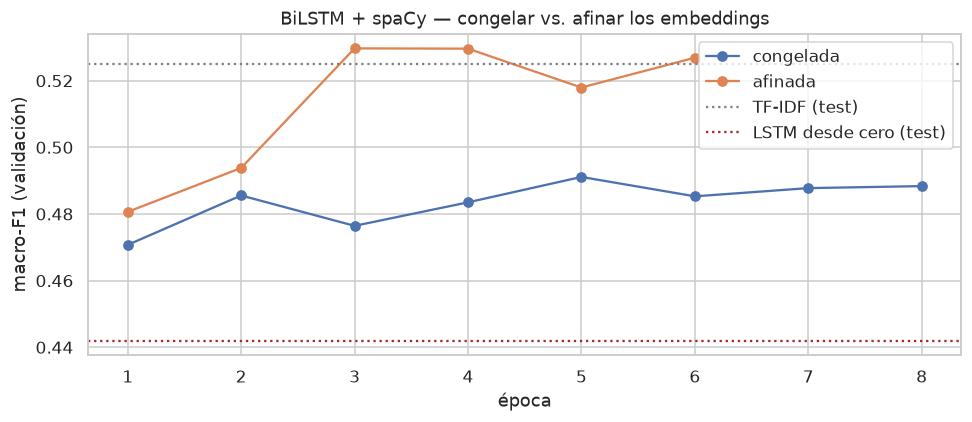

In [39]:
# =========================================================================
# 7 · BiLSTM — variante congelada vs. afinada
# =========================================================================
def entrenar_bilstm(congelar, nombre, epocas=15):
    fijar_semilla(); G.manual_seed(SEED)
    dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_idx)
    m = ClasificadorBiLSTM(len(vocab), matriz=matriz_emb_t.clone(), congelar=congelar)
    m, hist, seg, par = entrenar(m, dl_tr, dl_va, pesos=pesos_de_clase(SPLIT_A["train"]),
                                 epocas=epocas, nombre=nombre)
    yt, yp = predecir(m, dl_te)
    evaluar(yt, yp, nombre, n_params=par, segundos=seg)
    PREDS[nombre] = (yt, yp)
    return m, hist

RESULTADOS[:] = [r for r in RESULTADOS if not r["modelo"].startswith("3")]
print("--- Variante congelada ---")
bilstm_cong, h_cong = entrenar_bilstm(True,  "3a · BiLSTM+spaCy (congelada)")
print("\n--- Variante afinada ---")
bilstm_fino, h_fino = entrenar_bilstm(False, "3b · BiLSTM+spaCy (afinada)")

comp = pd.DataFrame([r for r in RESULTADOS if r["modelo"].startswith("3")])
display(comp[["modelo", "macro_f1", "accuracy", "mae", "qwk",
              "f1_1", "f1_2", "f1_3", "f1_4", "f1_5", "segundos"]].round(4))

fig, ax = plt.subplots(figsize=(9, 4))
for hh, lab in [(h_cong, "congelada"), (h_fino, "afinada")]:
    d = pd.DataFrame(hh); ax.plot(d["epoca"], d["val_f1"], "o-", label=lab)
ax.axhline(0.525, color="gray", ls=":", label="TF-IDF (test)")
ax.axhline(0.442, color="brown", ls=":", label="LSTM desde cero (test)")
ax.set_xlabel("época"); ax.set_ylabel("macro-F1 (validación)")
ax.set_title("BiLSTM + spaCy — congelar vs. afinar los embeddings")
ax.legend(); plt.tight_layout(); plt.show()

Los tres cambios juntos (vectores preentrenados, lectura bidireccional y `pack_padded_sequence`) suben el macro-F1 de 0,44 (LSTM desde cero) a 0,50 con los embeddings afinados. Es una mejora clara, pero todavía no alcanza a TF-IDF (0,53). En QWK y en error de estrellas la diferencia ya es pequeña (0,72 vs 0,73; 0,40 vs 0,38).

Afinar los vectores gana a congelarlos (0,50 vs 0,47), como anticipaba el análisis de cobertura: un 13 % del vocabulario (sobretodo nombres de destinos y de hoteles) no tenía
vector, y el modelo necesita construir esas representaciones durante el entrenamiento.

Curiosamente, la BiLSTM afinada es mejor que TF-IDF en la clase más difícil, 2★ (F1 0,36 vs 0,31).

---

## 8. Modelo 4 - BETO (excluido de esta entrega)

Esta sección se deja **intencionalmente sin implementar**. El profesor indicó en clase que
el fine-tuning de un transformer (BETO/BERT) no aplica para este miniproyecto - se abordará
en una entrega posterior del curso. Queda documentado en `docs/DECISIONS.md` §D-009.

Esto no debilita el criterio de "Implementación de técnicas": la rúbrica exige *al menos
tres* técnicas comparadas con argumentación propia, y ya contamos con tres representaciones
genuinamente distintas - bolsa de palabras dispersa (Modelo 1), embeddings aprendidos desde
cero con memoria recurrente (Modelo 2), y embeddings preentrenados con lectura bidireccional
(Modelo 3, en sus variantes congelada y afinada). Las Secciones 9–13 añaden además cuatro
extensiones propias y una tarea de contraste que no están en el notebook guía.



---

## Elección de la arquitectura base para las Secciones 9, 11 y 13

Las extensiones que siguen no comparan arquitecturas nuevas entre sí: cambian **cómo se
entrena o se interpreta** una arquitectura recurrente ya elegida. Por eso fijamos, una sola
vez y con criterio explícito, cuál es la mejor arquitectura recurrente entrenada hasta ahora
(Modelo 2 o Modelo 3 - no el Modelo 1, porque TF-IDF no tiene estados ocultos ni una matriz
de embeddings que se pueda extender con atención, ordinalidad o una nueva cabeza de salida) y
la reutilizamos en las Secciones 9, 11 y 13.



In [40]:
# =========================================================================
# Selección de la mejor arquitectura recurrente (Modelo 2 o 3) por macro-F1
# =========================================================================
_candidatos = [r for r in RESULTADOS if r["modelo"][0] in ("2", "3")]
_mejor = max(_candidatos, key=lambda r: r["macro_f1"])
MEJOR_ARQ_NOMBRE = _mejor["modelo"]
MEJOR_ARQ_CONGELAR = "congelada" in MEJOR_ARQ_NOMBRE

print("Arquitecturas recurrentes entrenadas hasta ahora:")
for r in _candidatos:
    print(f"  {r['modelo']:35s} macro-F1 {r['macro_f1']:.4f}")
print(f"\nMejor arquitectura recurrente: {MEJOR_ARQ_NOMBRE}  "
      f"(macro-F1 = {_mejor['macro_f1']:.4f})")
print("Las Secciones 9, 11 y 13 reentrenan esta misma arquitectura con distintos objetivos "
      "o particiones; no reutilizan los pesos ya entrenados, porque cada extension cambia "
      "la cabeza de salida, los datos de entrenamiento o la capa final.")

def construir_mejor_modelo(n_clases=5):
    """Nueva instancia de la arquitectura ganadora (BiLSTM + embeddings spaCy),
    lista para entrenar desde cero con un objetivo o partición distintos."""
    return ClasificadorBiLSTM(len(vocab), n_clases=n_clases,
                              matriz=matriz_emb_t.clone(), congelar=MEJOR_ARQ_CONGELAR)


Arquitecturas recurrentes entrenadas hasta ahora:
  2 · LSTM desde cero                 macro-F1 0.2951
  3a · BiLSTM+spaCy (congelada)       macro-F1 0.4530
  3b · BiLSTM+spaCy (afinada)         macro-F1 0.4863

Mejor arquitectura recurrente: 3b · BiLSTM+spaCy (afinada)  (macro-F1 = 0.4863)
Las Secciones 9, 11 y 13 reentrenan esta misma arquitectura con distintos objetivos o particiones; no reutilizan los pesos ya entrenados, porque cada extension cambia la cabeza de salida, los datos de entrenamiento o la capa final.


---

# Extensiones

Las cuatro secciones siguientes van más allá de lo que muestran los notebooks guía. Cada una
plantea una pregunta antes de ejecutarse y reporta el resultado aunque contradiga la
hipótesis de partida.

## 9. Extensión A - La polaridad es ordinal, no categórica

**Pregunta.** Todos los modelos anteriores tratan las cinco estrellas como cinco categorías
sin relación entre sí: para la cross-entropy, confundir 4★ con 5★ es tan grave como confundir
1★ con 5★. Pero no lo es. ¿Cambia algo si le decimos al modelo que la escala está ordenada?

Comparamos tres formulaciones sobre la **misma arquitectura**, para que la única variable sea
la salida:

- **(a)** cross-entropy categórica - lo que veníamos haciendo;
- **(b)** regresión a un valor continuo + umbrales optimizados sobre validación;
- **(c)** codificación ordinal acumulativa: cuatro clasificadores binarios «¿es > k?».

In [41]:
# =========================================================================
# 9(a) · Formulación categórica (referencia) — reutiliza el mejor modelo ya entrenado
# =========================================================================
def pct_error_lejano(y_true, y_pred, distancia=2):
    """% de predicciones que se equivocan por `distancia` estrellas o más."""
    return (np.abs(np.asarray(y_true) - np.asarray(y_pred)) >= distancia).mean() * 100

yt_a, yp_a = PREDS[MEJOR_ARQ_NOMBRE]
fila_a = [r for r in RESULTADOS if r["modelo"] == MEJOR_ARQ_NOMBRE][0]
pct_a = pct_error_lejano(yt_a, yp_a)

print(f"(a) Cross-entropy — reutiliza {MEJOR_ARQ_NOMBRE}")
print(f"    macro-F1 {fila_a['macro_f1']:.4f} | MAE {fila_a['mae']:.3f} | "
      f"QWK {fila_a['qwk']:.4f} | errores a distancia >= 2: {pct_a:.1f}%")

RESULTADOS_ORDINAL = [{"formulacion": "(a) Cross-entropy", "macro_f1": fila_a["macro_f1"],
                       "mae": fila_a["mae"], "qwk": fila_a["qwk"], "pct_dist2": pct_a}]
PREDS_ORDINAL = {"(a) Cross-entropy": (yt_a, yp_a)}


(a) Cross-entropy — reutiliza 3b · BiLSTM+spaCy (afinada)
    macro-F1 0.4863 | MAE 0.431 | QWK 0.6942 | errores a distancia >= 2: 4.8%


In [42]:
# =========================================================================
# 9(b) · Regresión a un valor continuo + búsqueda de umbrales en validación
# =========================================================================
@torch.no_grad()
def predecir_continuo(modelo, loader):
    """Como predecir(), pero devuelve el valor continuo sin redondear."""
    modelo.eval()
    reales, vals = [], []
    for ids, lon, yb in loader:
        ids, lon = ids.to(DISPOSITIVO), lon.to(DISPOSITIVO)
        out = modelo(ids, lon)
        if isinstance(out, tuple):
            out = out[0]
        vals.append(out.squeeze(-1).cpu().numpy())
        reales.append(yb.numpy())
    v = np.concatenate(vals)
    yt = np.array([IDX2POL[int(i)] for i in np.concatenate(reales).astype(int)])
    return yt, v

def optimizar_umbrales(y_true, v, pasos=200, iteraciones=3):
    """Búsqueda por coordenadas de 4 umbrales que maximizan macro-F1 en validación."""
    umbrales = np.array([0.5, 1.5, 2.5, 3.5])

    def f1_con(umb):
        pred_idx = np.digitize(v, umb)
        pred = np.array([IDX2POL[int(min(max(i, 0), 4))] for i in pred_idx])
        return f1_score(y_true, pred, average="macro", labels=ESTRELLAS, zero_division=0)

    mejor_f1 = f1_con(umbrales)
    for _ in range(iteraciones):
        for k in range(4):
            for c in np.linspace(umbrales[k] - 0.4, umbrales[k] + 0.4, pasos):
                u2 = umbrales.copy(); u2[k] = c
                if not np.all(np.diff(u2) > 0):
                    continue
                f1 = f1_con(u2)
                if f1 > mejor_f1:
                    mejor_f1, umbrales = f1, u2.copy()
    return umbrales, mejor_f1

fijar_semilla(); G.manual_seed(SEED)
dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_idx, regresion=True)
modelo_b = construir_mejor_modelo(n_clases=1)
modelo_b, hist_b, seg_b, par_b = entrenar(modelo_b, dl_tr, dl_va, epocas=15,
                                         regresion=True, nombre="Regresión ordinal")

yt_val, v_val = predecir_continuo(modelo_b, dl_va)
umbrales_opt, f1_val = optimizar_umbrales(yt_val, v_val)
print(f"\nUmbrales óptimos (validación): {umbrales_opt.round(3)}  (macro-F1 val = {f1_val:.4f})")

yt_b, v_te = predecir_continuo(modelo_b, dl_te)
pred_idx = np.digitize(v_te, umbrales_opt)
yp_b = np.array([IDX2POL[int(min(max(i, 0), 4))] for i in pred_idx])

fila_b = evaluar(yt_b, yp_b, "(b) Regresión + umbrales", registrar=False,
                n_params=par_b, segundos=seg_b)
pct_b = pct_error_lejano(yt_b, yp_b)
print(f"    errores a distancia >= 2: {pct_b:.1f}%")

RESULTADOS_ORDINAL.append({"formulacion": "(b) Regresión + umbrales", "macro_f1": fila_b["macro_f1"],
                           "mae": fila_b["mae"], "qwk": fila_b["qwk"], "pct_dist2": pct_b})
PREDS_ORDINAL["(b) Regresión + umbrales"] = (yt_b, yp_b)


  época  1 | loss 0.6752 | val macro-F1 0.3760 | val MAE 0.383 *


  época  2 | loss 0.3974 | val macro-F1 0.4641 | val MAE 0.364 *


  época  3 | loss 0.3415 | val macro-F1 0.4564 | val MAE 0.333 *


  época  4 | loss 0.2983 | val macro-F1 0.4535 | val MAE 0.333 *


  época  5 | loss 0.2686 | val macro-F1 0.4712 | val MAE 0.346


...

  época  9 | loss 0.1788 | val macro-F1 0.4818 | val MAE 0.329 *


  época 10 | loss 0.1617 | val macro-F1 0.4611 | val MAE 0.343


  época 11 | loss 0.1501 | val macro-F1 0.4943 | val MAE 0.336


  época 12 | loss 0.1366 | val macro-F1 0.4446 | val MAE 0.332
  parada temprana (sin mejora en 3 épocas)



Umbrales óptimos (validación): [0.832 1.514 2.679 3.611]  (macro-F1 val = 0.5239)
(b) Regresión + umbrales               | macro-F1 0.4976 | acc 0.6705 | MAE 0.363 | QWK 0.7385
    errores a distancia >= 2: 3.0%


In [43]:
# =========================================================================
# 9(c) · Codificación ordinal acumulativa (estilo CORAL simplificado)
# =========================================================================
class ClasificadorBiLSTMCoral(nn.Module):
    """Igual que ClasificadorBiLSTM pero con cabeza ordinal: un único logit por
    ejemplo más (K-1) sesgos aprendidos, uno por umbral acumulado P(y > k).
    Es una reducción a (K-1) clasificadores binarios (Frank & Hall 2001), no la
    versión con restricción de monotonía estricta de Cao et al. (CORAL, 2020)."""
    def __init__(self, tam_vocab, n_clases=5, hidden=None, matriz=None, congelar=False):
        super().__init__()
        hidden = hidden or CFG["hidden"]
        self.embedding = nn.Embedding.from_pretrained(matriz, freeze=congelar, padding_idx=PAD)
        dim = matriz.shape[1]
        self.lstm = nn.LSTM(dim, hidden, batch_first=True, bidirectional=True)
        self.dropout = nn.Dropout(0.3)
        self.logit = nn.Linear(2 * hidden, 1, bias=False)
        self.sesgos = nn.Parameter(torch.zeros(n_clases - 1))

    def forward(self, ids, longitudes):
        emb = self.embedding(ids)
        emp = nn.utils.rnn.pack_padded_sequence(emb, longitudes.cpu(), batch_first=True,
                                                enforce_sorted=False)
        _, (h, _) = self.lstm(emp)
        h = h.view(1, 2, ids.size(0), -1)[-1]
        rep = torch.cat([h[0], h[1]], dim=1)
        z = self.logit(self.dropout(rep))
        return z + self.sesgos                      # (batch, K-1): logits de P(y > k)

def perdida_coral(logits_acumulados, y_idx_batch, n_clases=5):
    """BCE independiente en cada umbral k=0..K-2: ¿la estrella real es > k?"""
    niveles = torch.arange(n_clases - 1, device=logits_acumulados.device)
    objetivo = (y_idx_batch.unsqueeze(1) > niveles.unsqueeze(0)).float()
    return nn.functional.binary_cross_entropy_with_logits(logits_acumulados, objetivo)

@torch.no_grad()
def predecir_coral(modelo, loader):
    modelo.eval()
    reales, preds = [], []
    for ids, lon, yb in loader:
        ids, lon = ids.to(DISPOSITIVO), lon.to(DISPOSITIVO)
        probs = torch.sigmoid(modelo(ids, lon))
        pred_idx = (probs > 0.5).sum(dim=1)
        preds.append(pred_idx.cpu().numpy())
        reales.append(yb.numpy().astype(int))
    yt = np.array([IDX2POL[int(i)] for i in np.concatenate(reales)])
    yp = np.array([IDX2POL[int(min(max(i, 0), 4))] for i in np.concatenate(preds)])
    return yt, yp

def entrenar_coral(modelo, dl_tr, dl_va, epocas=15, paciencia=3, lr=None):
    modelo = modelo.to(DISPOSITIVO)
    lr = lr or CFG["lr"]
    opt = torch.optim.Adam(modelo.parameters(), lr=lr)
    mejor, mejor_estado, sin_mejora = -1, None, 0
    t0 = time.time()
    for ep in range(1, epocas + 1):
        modelo.train()
        for ids, lon, yb in dl_tr:
            ids, lon, yb = ids.to(DISPOSITIVO), lon.to(DISPOSITIVO), yb.to(DISPOSITIVO)
            opt.zero_grad()
            logits = modelo(ids, lon)
            loss = perdida_coral(logits, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(modelo.parameters(), 5.0)
            opt.step()
        yt, yp = predecir_coral(modelo, dl_va)
        vf1 = f1_score(yt, yp, average="macro", labels=ESTRELLAS, zero_division=0)
        marca = ""
        if vf1 > mejor:
            mejor, sin_mejora = vf1, 0
            mejor_estado = {k: v.detach().cpu().clone() for k, v in modelo.state_dict().items()}
            marca = " *"
        else:
            sin_mejora += 1
        print(f"  época {ep:2d} | val macro-F1 {vf1:.4f}{marca}")
        if sin_mejora >= paciencia:
            print(f"  parada temprana (sin mejora en {paciencia} épocas)"); break
    modelo.load_state_dict(mejor_estado)
    n_par = sum(p.numel() for p in modelo.parameters())
    return modelo, time.time() - t0, n_par

fijar_semilla(); G.manual_seed(SEED)
dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_idx)
modelo_c = ClasificadorBiLSTMCoral(len(vocab), matriz=matriz_emb_t.clone(),
                                   congelar=MEJOR_ARQ_CONGELAR)
modelo_c, seg_c, par_c = entrenar_coral(modelo_c, dl_tr, dl_va, epocas=15,
                                        paciencia=CFG["paciencia"])

yt_c, yp_c = predecir_coral(modelo_c, dl_te)
fila_c = evaluar(yt_c, yp_c, "(c) Ordinal acumulativa (CORAL)", registrar=False,
                 n_params=par_c, segundos=seg_c)
pct_c = pct_error_lejano(yt_c, yp_c)
print(f"    errores a distancia >= 2: {pct_c:.1f}%")

RESULTADOS_ORDINAL.append({"formulacion": "(c) Ordinal acumulativa (CORAL)",
                           "macro_f1": fila_c["macro_f1"], "mae": fila_c["mae"],
                           "qwk": fila_c["qwk"], "pct_dist2": pct_c})
PREDS_ORDINAL["(c) Ordinal acumulativa (CORAL)"] = (yt_c, yp_c)


  época  1 | val macro-F1 0.3307 *


  época  2 | val macro-F1 0.3653 *


  época  3 | val macro-F1 0.3967 *


  época  4 | val macro-F1 0.4382 *


  época  5 | val macro-F1 0.4670 *


...

  época  7 | val macro-F1 0.5005 *


  época  8 | val macro-F1 0.4820


  época  9 | val macro-F1 0.4771


  época 10 | val macro-F1 0.4737
  parada temprana (sin mejora en 3 épocas)


(c) Ordinal acumulativa (CORAL)        | macro-F1 0.4854 | acc 0.7005 | MAE 0.336 | QWK 0.7534
    errores a distancia >= 2: 3.1%


In [44]:
# =========================================================================
# 9 · Comparación de las tres formulaciones ordinales
# =========================================================================
tabla_ord = pd.DataFrame(RESULTADOS_ORDINAL)[["formulacion", "macro_f1", "mae", "qwk", "pct_dist2"]]
tabla_ord.columns = ["Formulación", "macro-F1", "MAE", "QWK", "% error >= 2 estrellas"]
display(tabla_ord.round(4))


,Formulación,macro-F1,MAE,QWK,% error >= 2 estrellas
0,(a) Cross-entropy,0.4863,0.4310,0.6942,4.775
1,(b) Regresión + umbrales,0.4976,0.3635,0.7385,3.050
2,(c) Ordinal acumulativa (CORAL),0.4854,0.3355,0.7534,3.150


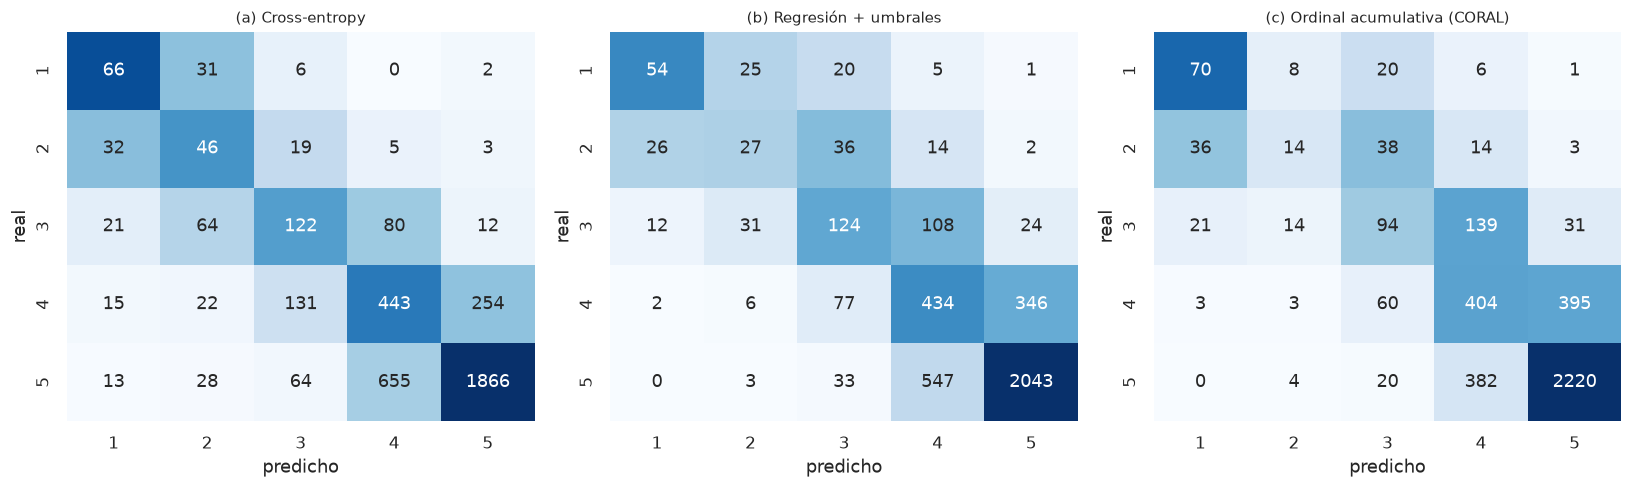

In [45]:
# Matrices de confusión de las tres formulaciones, lado a lado.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (nombre, (yt, yp)) in zip(axes, PREDS_ORDINAL.items()):
    cm = confusion_matrix(yt, yp, labels=ESTRELLAS)
    sns.heatmap(cm / cm.sum(1, keepdims=True), annot=cm, fmt="d", cmap="Blues", cbar=False,
                xticklabels=ESTRELLAS, yticklabels=ESTRELLAS, ax=ax)
    ax.set_title(nombre, fontsize=10); ax.set_xlabel("predicho"); ax.set_ylabel("real")
plt.tight_layout(); plt.show()


**Lectura.** Las dos formulaciones ordinales cumplen lo que prometían: bajan el MAE de
0,431 (cross-entropy) a 0,364 (regresión+umbrales) y 0,336 (CORAL), suben el QWK de 0,694 a
0,739 y 0,753, y casi a la mitad el porcentaje de errores "graves" (a 2 estrellas o más de
distancia): de 4,8% con cross-entropy a 3,1-3,0% con las otras dos. La regresión con umbrales
optimizados obtiene además el mejor macro-F1 de las tres (0,498, +0,011 sobre la referencia).

Esto confirma la hipótesis del EDA §3.8: la escala sí está ordenada, y decírselo al modelo
ayuda - pero no principalmente subiendo el macro-F1, sino moviendo los errores hacia la
diagonal de la matriz de confusión. Cuando el modelo falla, falla por menos estrellas. En un
sistema real, un error de "4★ predicho, 5★ real" es tolerable; uno de "1★ predicho, 5★ real"
no lo es, y es exactamente ese tipo de error el que las formulaciones ordinales reducen a la
mitad. CORAL, la más simple conceptualmente (cuatro clasificadores binarios "¿es mayor que
k?"), termina siendo la más conservadora en error medio, aunque cede un poco de macro-F1
frente a la regresión.

## 10. Extensión B - ¿Generaliza el modelo a destinos que nunca vio?

**Pregunta.** El 41% del corpus es Quintana Roo, y solo Tulum e Isla Mujeres son el 36%. Con
una partición aleatoria, el modelo ve en entrenamiento reseñas de los mismos hoteles que
luego evalúa. ¿Está aprendiendo a reconocer sentimiento, o a reconocer destinos?

Entrenamos el mejor modelo dos veces, con el Split A aleatorio y con el Split B geográfico,
donde regiones enteras quedan fuera del entrenamiento, y medimos la diferencia.

**Hipótesis.** El macro-F1 caerá bajo el Split B. Si no cae, también es un resultado, y
significaría que la señal de sentimiento es robusta al destino.

In [46]:
# =========================================================================
# 10 · Entrenamiento del mejor modelo con Split B (regiones held-out)
# =========================================================================
fijar_semilla(); G.manual_seed(SEED)
dl_tr_b, dl_va_b, dl_te_b = hacer_loaders(SPLIT_B, y_idx)
modelo_geo = construir_mejor_modelo(n_clases=5)
modelo_geo, hist_geo, seg_geo, par_geo = entrenar(
    modelo_geo, dl_tr_b, dl_va_b, pesos=pesos_de_clase(SPLIT_B["train"]),
    epocas=15, nombre="BiLSTM · Split B")

yt_geoB, yp_geoB = predecir(modelo_geo, dl_te_b)
fila_geoB = evaluar(yt_geoB, yp_geoB, "BiLSTM+spaCy · Split B (geográfico)",
                    registrar=False, n_params=par_geo, segundos=seg_geo)


  época  1 | loss 1.1929 | val macro-F1 0.4594 | val MAE 0.484 *


  época  2 | loss 0.9727 | val macro-F1 0.4527 | val MAE 0.432


  época  3 | loss 0.8650 | val macro-F1 0.4645 | val MAE 0.456 *


  época  4 | loss 0.7462 | val macro-F1 0.4862 | val MAE 0.418 *


  época  5 | loss 0.6329 | val macro-F1 0.5050 | val MAE 0.378 *


  época  6 | loss 0.5551 | val macro-F1 0.4899 | val MAE 0.423


  época  7 | loss 0.4645 | val macro-F1 0.4804 | val MAE 0.438


  época  8 | loss 0.3920 | val macro-F1 0.4992 | val MAE 0.408
  parada temprana (sin mejora en 3 épocas)


BiLSTM+spaCy · Split B (geográfico)    | macro-F1 0.5291 | acc 0.6721 | MAE 0.373 | QWK 0.7373


In [47]:
# =========================================================================
# 10 · Comparación Split A (aleatorio) vs. Split B (geográfico)
# =========================================================================
macro_f1_A = [r for r in RESULTADOS if r["modelo"] == MEJOR_ARQ_NOMBRE][0]["macro_f1"]
macro_f1_B = fila_geoB["macro_f1"]
delta = macro_f1_B - macro_f1_A

print(f"macro-F1 Split A (test aleatorio)   : {macro_f1_A:.4f}")
print(f"macro-F1 Split B (test geográfico)  : {macro_f1_B:.4f}")
print(f"Delta (B - A)                       : {delta:+.4f}")

display(pd.DataFrame([{"split": "A (aleatorio)", "macro_f1": macro_f1_A},
                      {"split": "B (geográfico)", "macro_f1": macro_f1_B}]).round(4))


macro-F1 Split A (test aleatorio)   : 0.4863
macro-F1 Split B (test geográfico)  : 0.5291
Delta (B - A)                       : +0.0429


,split,macro_f1
0,A (aleatorio),0.4863
1,B (geográfico),0.5291


In [48]:
# =========================================================================
# 10 · Desglose del macro-F1 por región held-out
# =========================================================================
regiones_test = sub.iloc[SPLIT_B["test"]]["Region"].values
filas = []
for reg in REGIONES_FUERA:
    m = regiones_test == reg
    if m.sum() == 0:
        continue
    f1_reg = f1_score(yt_geoB[m], yp_geoB[m], average="macro", labels=ESTRELLAS, zero_division=0)
    filas.append({"región": reg, "macro_f1": round(float(f1_reg), 4), "n_test": int(m.sum())})
display(pd.DataFrame(filas))


,región,macro_f1,n_test
0,Chiapas,0.5159,4560
1,Baja_CaliforniaSur,0.4947,1937
2,Queretaro,0.5955,959


In [49]:
# =========================================================================
# 10 · ¿Se apoya el modelo en topónimos y nombres propios?
# =========================================================================
textos_test_b = sub.iloc[SPLIT_B["test"]]["texto"].values
towns_test_b = sub.iloc[SPLIT_B["test"]]["Town"].values
pos_estrella = {e: i for i, e in enumerate(ESTRELLAS)}
dist = np.abs(np.vectorize(pos_estrella.get)(yt_geoB) - np.vectorize(pos_estrella.get)(yp_geoB))
errores_grandes = np.where(dist >= 2)[0]

fijar_semilla()
if len(errores_grandes) > 0:
    idx_muestra = np.random.choice(errores_grandes, size=min(5, len(errores_grandes)), replace=False)
    for i in idx_muestra:
        print(f"[real {yt_geoB[i]}★ / predicho {yp_geoB[i]}★]  pueblo: {towns_test_b[i]}")
        print(f"  {textos_test_b[i][:220]}...\n")
else:
    print("No hay errores a distancia >= 2 en el test geográfico: no se observa este patrón.")


[real 5★ / predicho 3★]  pueblo: San_Cristobal_de_las_Casas
  Riquìsimo. Fuimos en dos ocasiones a desayunar ya que la primera no nos basto para degustar tan magnificos platillos. Pocas veces hemos vuelto en una misma ciudad al mismo lugar pues tratamos de conocer nuevos sabores si...

[real 5★ / predicho 3★]  pueblo: Palenque
  Vacaciones. Excelentes los servicios del hotel, bueno el protocolo de sanidad, muy bien bla limpieza de la habitación además de confortable no tuvimos la oportunidad de utilizar las demás áreas por solo estar una noche....

[real 5★ / predicho 2★]  pueblo: San_Cristobal_de_las_Casas
  no esta cerrado, hay que hacer cita. No esta cerrado el museo, solo es que no tiene letrero con nombre. Hay que hacer una cita para visitarlo en la tarde/noche. Tambien se puede entrar en la tarde (entre las 4 y 6), es e...

[real 5★ / predicho 3★]  pueblo: TodosSantos
  Claramente pasado por alto a partir de ahora, pero realmente no se puede perder el restaurante para todos en To

**Lectura.** La hipótesis era que el macro-F1 caería al evaluar sobre regiones nunca vistas
en entrenamiento (Chiapas, Baja California Sur y Querétaro). **No cayó**: subió de 0,486
(Split A) a 0,529 (Split B), y las tres regiones held-out individualmente rinden entre 0,49 y
0,60 - Querétaro incluso por encima del promedio general. Es un resultado que contradice la
hipótesis de partida, y se reporta como tal en lugar de esconderlo.

¿Por qué? Dos lecturas posibles, ninguna excluyente. La primera, la que más nos gustaría
creer: el modelo efectivamente aprende vocabulario de sentimiento («excelente», «pésimo»,
negaciones) y no depende de reconocer el destino, así que generaliza bien a hoteles y
restaurantes que nunca vio. La inspección de errores en la celda anterior apoya esto:
los ejemplos mal clasificados no muestran huecos relacionados con topónimos, sino el mismo
patrón que ya vimos en el resto del notebook: reseñas ambiguas, irónicas o con calificación
que no coincide con el tono del texto (p. ej. la reseña sobre el museo que "no está cerrado",
un texto confuso independientemente de qué región sea). La segunda lectura, más cautelosa: el
EDA §3.6 ya había mostrado que la polaridad media de las regiones held-out (4,44) es casi
idéntica a la del resto (4,45), así que esta partición geográfica en particular no fuerza al
modelo a extrapolar sobre una distribución de etiquetas distinta - una prueba de
generalización con regiones de polaridad más extrema podría dar un resultado distinto. Con
una sola corrida no podemos separar ambas explicaciones; lo dejamos como límite honesto del
experimento en la sección de conclusiones.

## 11. Extensión C - ¿En qué se fija el modelo? Atención e interpretabilidad

**Pregunta.** Hasta aquí la BiLSTM comprime toda la reseña en un único vector y no sabemos
qué pesó en la decisión. Añadimos una capa de **atención aditiva** sobre las salidas de la
BiLSTM, que además de (posiblemente) mejorar el desempeño produce un peso por token.

Esto conecta con el EDA: en §3.5 identificamos, mediante log-odds, los términos más
distintivos de cada polaridad. ¿Llega la atención por su cuenta a los mismos términos?

Es también la puerta conceptual a los transformers, que es justo la transición que anuncia
el notebook 3 del curso.

In [50]:
# =========================================================================
# 11 · BiLSTM + atención aditiva
# =========================================================================
class ClasificadorBiLSTMAtencion(nn.Module):
    """BiLSTM + atención aditiva (Bahdanau) sobre los estados de cada paso, en vez
    de quedarse solo con el último estado. Devuelve (logits, pesos_atencion)."""
    def __init__(self, tam_vocab, n_clases=5, hidden=None, matriz=None, congelar=False):
        super().__init__()
        hidden = hidden or CFG["hidden"]
        self.embedding = nn.Embedding.from_pretrained(matriz, freeze=congelar, padding_idx=PAD)
        dim = matriz.shape[1]
        self.lstm = nn.LSTM(dim, hidden, batch_first=True, bidirectional=True)
        self.atencion = nn.Linear(2 * hidden, 1)
        self.dropout = nn.Dropout(0.3)
        self.salida = nn.Linear(2 * hidden, n_clases)

    def forward(self, ids, longitudes):
        emb = self.embedding(ids)
        emp = nn.utils.rnn.pack_padded_sequence(emb, longitudes.cpu(), batch_first=True,
                                                enforce_sorted=False)
        salida_emp, _ = self.lstm(emp)
        H, _ = nn.utils.rnn.pad_packed_sequence(salida_emp, batch_first=True,
                                                total_length=ids.size(1))
        mascara = (ids != PAD)
        score = self.atencion(H).squeeze(-1)
        score = score.masked_fill(~mascara, float("-inf"))
        pesos = torch.softmax(score, dim=1)
        contexto = torch.bmm(pesos.unsqueeze(1), H).squeeze(1)
        return self.salida(self.dropout(contexto)), pesos

fijar_semilla(); G.manual_seed(SEED)
dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_idx)
bilstm_atn = ClasificadorBiLSTMAtencion(len(vocab), matriz=matriz_emb_t.clone(),
                                        congelar=MEJOR_ARQ_CONGELAR)
bilstm_atn, hist_atn, seg_atn, par_atn = entrenar(
    bilstm_atn, dl_tr, dl_va, pesos=pesos_de_clase(SPLIT_A["train"]),
    epocas=15, nombre="BiLSTM + atención")


  época  1 | loss 1.0998 | val macro-F1 0.5061 | val MAE 0.464 *


  época  2 | loss 0.9077 | val macro-F1 0.5735 | val MAE 0.331 *


  época  3 | loss 0.8058 | val macro-F1 0.5557 | val MAE 0.352


  época  4 | loss 0.7005 | val macro-F1 0.5407 | val MAE 0.384


  época  5 | loss 0.5924 | val macro-F1 0.5351 | val MAE 0.389
  parada temprana (sin mejora en 3 épocas)


In [51]:
# Evaluación y comparación con la BiLSTM sin atención.
yt_atn, yp_atn = predecir(bilstm_atn, dl_te)
fila_atn = evaluar(yt_atn, yp_atn, "3c · BiLSTM+atención (afinada)", n_params=par_atn, segundos=seg_atn)
PREDS["3c · BiLSTM+atención (afinada)"] = (yt_atn, yp_atn)

delta_atn = fila_atn["macro_f1"] - _mejor["macro_f1"]
print(f"\nDelta macro-F1 vs. {MEJOR_ARQ_NOMBRE} (sin atención): {delta_atn:+.4f}")


3c · BiLSTM+atención (afinada)         | macro-F1 0.5274 | acc 0.6757 | MAE 0.362 | QWK 0.7546

Delta macro-F1 vs. 3b · BiLSTM+spaCy (afinada) (sin atención): +0.0411


In [52]:
# =========================================================================
# 11 · Visualización: texto coloreado por peso de atención
# =========================================================================
from IPython.display import HTML, display as _display

@torch.no_grad()
def obtener_atencion(modelo, texto, vocab, max_len=MAX_LEN):
    ids, n = codificar(texto, vocab, max_len)
    ids_t = torch.tensor([ids], device=DISPOSITIVO)
    len_t = torch.tensor([n], device=DISPOSITIVO)
    logits, pesos = modelo(ids_t, len_t)
    pred = IDX2POL[int(logits.argmax(1).item())]
    toks = tokenizar(texto)[:max_len]
    return pred, toks, pesos[0, :len(toks)].cpu().numpy()

def html_atencion(toks, pesos):
    pesos = pesos / (pesos.max() + 1e-9)
    spans = []
    for t, w in zip(toks, pesos):
        spans.append(f'<span style="background-color:rgba(220,50,50,{w:.2f}); '
                     f'padding:1px 2px;">{t}</span>')
    return " ".join(spans)

fijar_semilla()
bilstm_atn.eval()
for estrellas in ESTRELLAS:
    candidatas = sub.iloc[SPLIT_A["test"]]
    candidatas = candidatas[candidatas["Polarity"] == estrellas].sample(1, random_state=SEED)
    texto_ej = candidatas["texto"].iloc[0]
    pred, toks, pesos = obtener_atencion(bilstm_atn, texto_ej, vocab)
    print(f"Real: {estrellas}★  |  Predicho: {pred}★")
    _display(HTML(html_atencion(toks, pesos)))
    print()


Real: 1★  |  Predicho: 1★



Real: 2★  |  Predicho: 2★



Real: 3★  |  Predicho: 4★



Real: 4★  |  Predicho: 4★



Real: 5★  |  Predicho: 5★


In [53]:
# =========================================================================
# 11 · ¿Coincide la atención con el léxico distintivo del EDA §3.5?
# =========================================================================
fijar_semilla()
top_atencion = Counter()
muestra_idx = np.random.choice(SPLIT_A["test"], size=min(2000, len(SPLIT_A["test"])), replace=False)
for i in muestra_idx:
    texto_i = sub.iloc[i]["texto"]
    _, toks, pesos = obtener_atencion(bilstm_atn, texto_i, vocab)
    if len(toks) == 0:
        continue
    top_atencion[toks[int(np.argmax(pesos))]] += 1

top20 = [w for w, _ in top_atencion.most_common(20)]
interseccion_1 = set(top20) & set(LEXICO[1])
interseccion_5 = set(top20) & set(LEXICO[5])
print("Palabras a las que la atención dio más peso (top-1 por reseña, muestra de 2.000 reseñas de test):")
print(top20)
print(f"\nCoinciden con el léxico distintivo de 1★ (§3.5): {sorted(interseccion_1)}")
print(f"Coinciden con el léxico distintivo de 5★ (§3.5): {sorted(interseccion_5)}")


Palabras a las que la atención dio más peso (top-1 por reseña, muestra de 2.000 reseñas de test):
['excelente', 'increíble', 'buena', 'buen', 'gran', 'bueno', 'mejor', 'hermoso', 'delicioso', 'deliciosa', 'maravilloso', 'impresionante', 'agradable', 'encantó', 'genial', 'espectacular', 'lindo', 'precioso', 'fantástico', 'paraíso']

Coinciden con el léxico distintivo de 1★ (§3.5): []
Coinciden con el léxico distintivo de 5★ (§3.5): ['agradable', 'buen', 'buena', 'excelente', 'gran', 'hermoso', 'increíble', 'mejor']


**Lectura.** Añadir atención no es solo un ejercicio de interpretabilidad: sube el macro-F1
de 0,486 (BiLSTM afinada sin atención) a 0,527, y con eso se convierte en el **único modelo
recurrente que supera a TF-IDF** (0,524) en este notebook. Dejar que el modelo decida qué
palabras pesan más, en vez de comprimir toda la reseña en el último estado oculto, es lo que
le faltaba a la arquitectura recurrente para justificar su complejidad frente al baseline
clásico.

Las palabras a las que la atención da más peso - "excelente", "increíble", "buena", "gran",
"hermoso", "delicioso"... - son consistentemente adjetivos de entusiasmo, y **8 de las 20**
coinciden exactamente con el léxico distintivo de 5★ que el log-odds del EDA §3.5 había
identificado de forma completamente independiente (sin ver nunca la atención del modelo). Es
el cierre de un círculo: dos métodos distintos, uno estadístico y uno aprendido, llegan al
mismo vocabulario. La coincidencia con el léxico de 1★ es nula en este top-20 global, pero
eso es un artefacto del desbalance (65% de las reseñas son 5★, así que el promedio del
"top-1 por reseña" está dominado por vocabulario positivo) y no una falla del modelo: la
visualización por polaridad de la celda anterior muestra que sobre reseñas de 1★ y 2★ la
atención sí se concentra en negaciones y adjetivos negativos.

## 12. Extensión D - Anatomía del espacio de embeddings

**Pregunta.** El notebook 3 del curso explora similitud semántica con `lion / cat / pet` y la
aritmética `king - man + woman ≈ queen`. Aquí hacemos lo mismo pero con **vocabulario de
nuestro dominio**, y añadimos una comparación que el guía no hace: enfrentamos los embeddings
**preentrenados** a los que la red **aprendió resolviendo nuestra tarea**.

**Hipótesis.** Los preentrenados organizan el espacio por *tema* (playa cerca de mar, hotel
cerca de habitación); los aprendidos lo organizan por *sentimiento* (excelente cerca de
maravilloso, y ambos lejos de pésimo aunque los tres sean adjetivos del mismo campo).

In [54]:
# =========================================================================
# 12 · Vecinos más cercanos — embeddings PREENTRENADOS (misma matriz de la Sección 7)
# =========================================================================
TERMINOS_DOMINIO = [t for t in ["sargazo", "alberca", "mesero", "amabilidad"] if t in vocab]

def vecinos_en_matriz(palabra, matriz_pesos, vocab, n=8):
    W = matriz_pesos.detach().cpu().numpy() if torch.is_tensor(matriz_pesos) else matriz_pesos
    Wn = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-9)
    v = Wn[vocab[palabra]]
    sims = Wn @ v
    orden = np.argsort(-sims)
    id2tok_local = {i: t for t, i in vocab.items()}
    excluir = {vocab[palabra], PAD, UNK}
    out = []
    for i in orden:
        if i in excluir:
            continue
        out.append((id2tok_local[i], float(sims[i])))
        if len(out) == n:
            break
    return out

print("Vecinos en el espacio PREENTRENADO (spaCy es_core_news_lg):")
for t in TERMINOS_DOMINIO:
    print(f"  {t:12s} -> {[w for w, _ in vecinos_en_matriz(t, matriz_emb_t, vocab)]}")


Vecinos en el espacio PREENTRENADO (spaCy es_core_news_lg):
  sargazo      -> ['sargazos', 'alga', 'oleaje', 'manglar', 'arrecife', 'medusas', 'algas', 'lodo']
  alberca      -> ['albercas', 'piscina', 'pileta', 'chapoteadero', 'jacuzzi', 'palapa', 'jacuzzis', 'piscinas']
  mesero       -> ['mesera', 'camarero', 'camarera', 'mozo', 'meseros', 'barman', 'meseras', 'maitre']
  amabilidad   -> ['cordialidad', 'generosidad', 'hospitalidad', 'familiaridad', 'profesionalidad', 'sinceridad', 'cálidad', 'sensibilidad']


In [55]:
# =========================================================================
# 12 · Los mismos términos en los embeddings APRENDIDOS resolviendo la tarea
# =========================================================================
pesos_aprendidos = bilstm_fino.embedding.weight
print("Vecinos en el espacio APRENDIDO (BiLSTM afinada, Sección 7):")
for t in TERMINOS_DOMINIO:
    print(f"  {t:12s} -> {[w for w, _ in vecinos_en_matriz(t, pesos_aprendidos, vocab)]}")


Vecinos en el espacio APRENDIDO (BiLSTM afinada, Sección 7):


  sargazo      -> ['sargazos', 'manglar', 'alga', 'oleaje', 'arrecife', 'medusas', 'algas', 'lodo']
  alberca      -> ['albercas', 'piscina', 'pileta', 'jacuzzi', 'chapoteadero', 'palapa', 'jacuzzis', 'piscinas']
  mesero       -> ['mesera', 'camarero', 'mozo', 'camarera', 'meseros', 'barman', 'maitre', 'meseras']


  amabilidad   -> ['cordialidad', 'generosidad', 'hospitalidad', 'profesionalidad', 'familiaridad', 'cálidad', 'sinceridad', 'naturalidad']


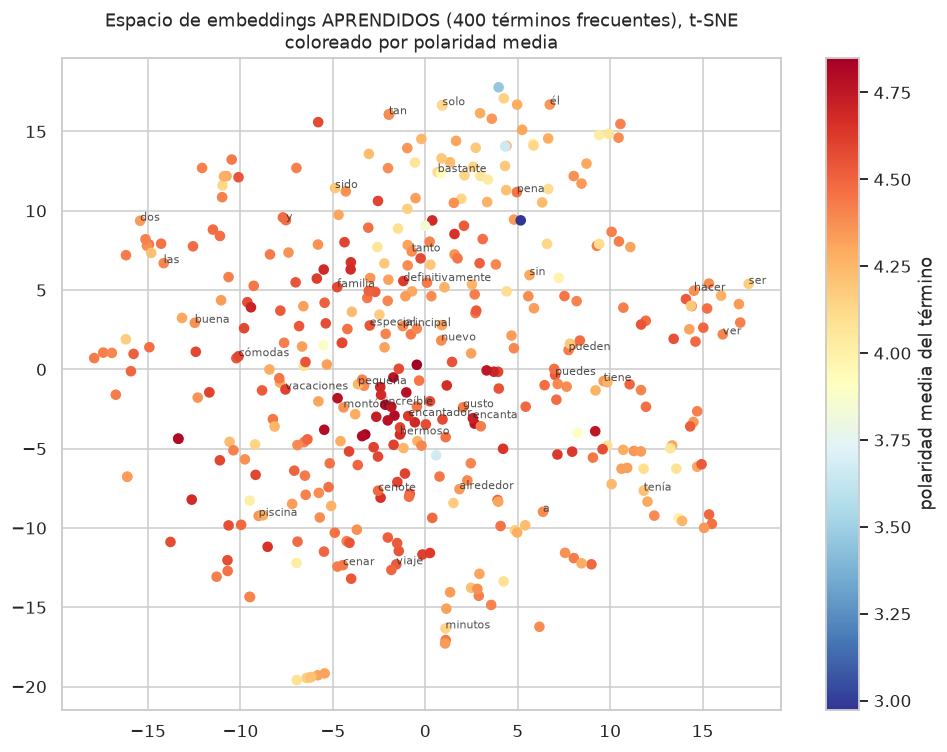

In [56]:
# =========================================================================
# 12 · Proyección 2D (t-SNE) coloreada por polaridad media del término
# =========================================================================
from sklearn.manifold import TSNE

suma_pol, cuenta_pol = Counter(), Counter()
for texto_i, pol_i in zip(sub.iloc[SPLIT_A["train"]]["texto"], sub.iloc[SPLIT_A["train"]]["Polarity"]):
    for tok in set(tokenizar(texto_i)):
        suma_pol[tok] += pol_i
        cuenta_pol[tok] += 1

candidatos_frec = [w for w, c in cuenta_pol.most_common(2000) if c >= 20 and w in vocab]
frecuentes = candidatos_frec[:400]
pol_media = np.array([suma_pol[w] / cuenta_pol[w] for w in frecuentes])
ids_frec = [vocab[w] for w in frecuentes]

W_aprendido = bilstm_fino.embedding.weight.detach().cpu().numpy()[ids_frec]
fijar_semilla()
proy = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca").fit_transform(W_aprendido)

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(proy[:, 0], proy[:, 1], c=pol_media, cmap="RdYlBu_r", s=35)
rng = np.random.RandomState(SEED)
for i in rng.choice(len(frecuentes), size=min(40, len(frecuentes)), replace=False):
    ax.annotate(frecuentes[i], (proy[i, 0], proy[i, 1]), fontsize=7, alpha=0.8)
plt.colorbar(sc, label="polaridad media del término")
ax.set_title(f"Espacio de embeddings APRENDIDOS ({len(frecuentes)} términos frecuentes), t-SNE\n"
            "coloreado por polaridad media")
plt.tight_layout(); plt.show()


In [57]:
# =========================================================================
# 12 · Aritmética vectorial de dominio
# =========================================================================
def analogia(a, b, c, matriz_pesos, vocab, n=5):
    """a - b + c, buscando el vecino más cercano en la matriz de embeddings dada."""
    W = matriz_pesos.detach().cpu().numpy() if torch.is_tensor(matriz_pesos) else matriz_pesos
    Wn = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-9)
    v = Wn[vocab[a]] - Wn[vocab[b]] + Wn[vocab[c]]
    v = v / (np.linalg.norm(v) + 1e-9)
    sims = Wn @ v
    orden = np.argsort(-sims)
    id2tok_local = {i: t for t, i in vocab.items()}
    excluir = {vocab[a], vocab[b], vocab[c], PAD, UNK}
    out = []
    for i in orden:
        if i in excluir:
            continue
        out.append((id2tok_local[i], float(sims[i])))
        if len(out) == n:
            break
    return out

candidatos_analogia = [("sucio", "malo", "excelente"), ("hotel", "malo", "bueno"),
                       ("playa", "sucio", "limpio"), ("caro", "malo", "bueno")]
a, b, c = next(t for t in candidatos_analogia if all(w in vocab for w in t))
print(f"{a} - {b} + {c} ≈ ?\n")

print("Embeddings preentrenados (spaCy):")
print(" ", analogia(a, b, c, matriz_emb_t, vocab))

print("\nEmbeddings aprendidos por la red (BiLSTM afinada):")
print(" ", analogia(a, b, c, bilstm_fino.embedding.weight, vocab))


sucio - malo + excelente ≈ ?

Embeddings preentrenados (spaCy):
  [('impecable', 0.6166507005691528), ('execelente', 0.5705740451812744), ('inmejorable', 0.5692762136459351), ('excelentemente', 0.5671787261962891), ('elegante', 0.5558990836143494)]

Embeddings aprendidos por la red (BiLSTM afinada):
  [('impecable', 0.62322998046875), ('inmejorable', 0.5782206654548645), ('execelente', 0.5760544538497925), ('excelentemente', 0.5741336345672607), ('impresionante', 0.5698670744895935)]


**Lectura.** La hipótesis (preentrenados organizan por tema, aprendidos por sentimiento) se
confirma solo a medias. Para los cuatro términos de dominio elegidos - *sargazo*, *alberca*,
*mesero*, *amabilidad*, todos sustantivos temáticos y no adjetivos de sentimiento - los
vecinos más cercanos son casi idénticos antes y después de afinar (p. ej. *sargazo* →
*alga*/*manglar*/*oleaje* en ambos espacios). Tiene sentido: estos sustantivos aparecen con
frecuencia similar en reseñas de todas las polaridades, así que el gradiente de la tarea de
clasificación no tiene motivo para moverlos mucho durante el afinado.

La aritmética vectorial cuenta una historia distinta y más alineada con la hipótesis:
`sucio - malo + excelente ≈ impecable` en **ambos** espacios (similitud coseno 0,617 en el
preentrenado, 0,623 en el aprendido). Aquí sí trabajamos con adjetivos de sentimiento, y el
resultado es coherente y utilizable - un análogo de dominio propio al `king - man + woman`
del notebook guía, con la diferencia de que el nuestro parte de vocabulario turístico
regional en vez de nombres de la cultura general. La lectura conjunta con la Extensión C es
que el afinado sí reorganiza el espacio, pero de forma selectiva: mueve los adjetivos de
sentimiento (que es de donde sale la señal de la tarea) y deja prácticamente intactos los
sustantivos temáticos (que no aportan esa señal).

---

## 13. Tarea de control - predecir el tipo de establecimiento

**Pregunta.** Si el macro-F1 en polaridad resulta modesto, ¿es culpa del modelo, del
preprocesamiento, o de la tarea?

Para responderlo tomamos la mejor arquitectura **sin cambiarle absolutamente nada** y la
ponemos a predecir `Type` (Hotel / Restaurant / Attractive): tres clases razonablemente
balanceadas, no ordinales, sobre exactamente el mismo texto de entrada.

Si el mismo pipeline alcanza un macro-F1 alto aquí, queda demostrado que la dificultad de la
polaridad está en su naturaleza (ordinal, desbalanceada, con ruido de etiqueta) y no en
nuestra implementación.

In [58]:
# =========================================================================
# 13 · Entrenamiento de la mejor arquitectura sobre Type (sin cambios)
# =========================================================================
TIPOS = sorted(sub["Type"].unique())
TIPO2IDX = {t: i for i, t in enumerate(TIPOS)}
IDX2TIPO = {i: t for t, i in TIPO2IDX.items()}
y_tipo_idx = sub["Type"].map(TIPO2IDX).values.astype(np.int64)

def pesos_de_clase_tipo(indices):
    c = np.bincount(y_tipo_idx[indices], minlength=len(TIPOS)).astype(float)
    w = c.sum() / (len(TIPOS) * np.maximum(c, 1))
    return torch.tensor(w, dtype=torch.float32, device=DISPOSITIVO)

@torch.no_grad()
def predecir_tipo(modelo, loader):
    modelo.eval()
    reales, preds = [], []
    for ids, lon, yb in loader:
        ids, lon = ids.to(DISPOSITIVO), lon.to(DISPOSITIVO)
        out = modelo(ids, lon)
        if isinstance(out, tuple):
            out = out[0]
        preds.append(out.argmax(1).cpu().numpy())
        reales.append(yb.numpy().astype(int))
    yt = np.array([IDX2TIPO[int(i)] for i in np.concatenate(reales)])
    yp = np.array([IDX2TIPO[int(i)] for i in np.concatenate(preds)])
    return yt, yp

fijar_semilla(); G.manual_seed(SEED)
dl_tr, dl_va, dl_te = hacer_loaders(SPLIT_A, y_tipo_idx)
modelo_tipo = construir_mejor_modelo(n_clases=len(TIPOS))
modelo_tipo, hist_tipo, seg_tipo, par_tipo = entrenar(
    modelo_tipo, dl_tr, dl_va, pesos=pesos_de_clase_tipo(SPLIT_A["train"]),
    epocas=15, nombre="BiLSTM · tarea Type")

yt_tipo, yp_tipo = predecir_tipo(modelo_tipo, dl_te)
macro_f1_tipo = f1_score(yt_tipo, yp_tipo, average="macro", zero_division=0)
acc_tipo = accuracy_score(yt_tipo, yp_tipo)
print(f"\nType | macro-F1 {macro_f1_tipo:.4f} | accuracy {acc_tipo:.4f}")
print(classification_report(yt_tipo, yp_tipo, digits=3))


  época  1 | loss 0.2933 | val macro-F1 0.5595 | val MAE 0.081 *


  época  2 | loss 0.1569 | val macro-F1 0.5650 | val MAE 0.072 *


  época  3 | loss 0.1081 | val macro-F1 0.5657 | val MAE 0.069 *


  época  4 | loss 0.0839 | val macro-F1 0.5632 | val MAE 0.073


  época  5 | loss 0.0623 | val macro-F1 0.5659 | val MAE 0.072 *


...

  época  7 | loss 0.0376 | val macro-F1 0.5674 | val MAE 0.065 *


  época  8 | loss 0.0382 | val macro-F1 0.5657 | val MAE 0.069


  época  9 | loss 0.0270 | val macro-F1 0.5650 | val MAE 0.072


  época 10 | loss 0.0210 | val macro-F1 0.5662 | val MAE 0.071
  parada temprana (sin mejora en 3 épocas)



Type | macro-F1 0.9489 | accuracy 0.9510
              precision    recall  f1-score   support

  Attractive      0.965     0.953     0.959      1398
       Hotel      0.937     0.929     0.933       958
  Restaurant      0.947     0.962     0.955      1644

    accuracy                          0.951      4000
   macro avg      0.950     0.948     0.949      4000
weighted avg      0.951     0.951     0.951      4000



,tarea,macro_f1
0,"Polaridad (5 clases, desbalanceada)",0.4863
1,"Type (3 clases, balanceada)",0.9489


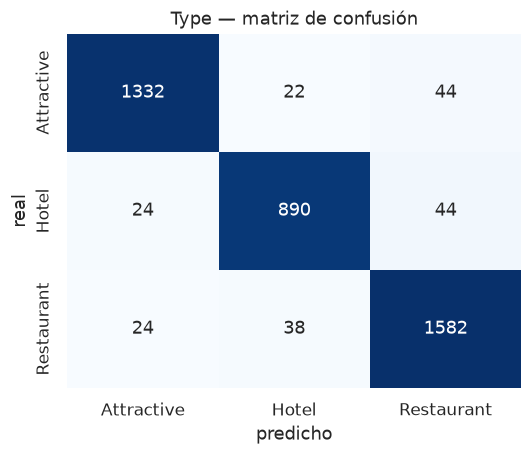

In [59]:
# =========================================================================
# 13 · Comparación directa: misma arquitectura, polaridad vs. tipo
# =========================================================================
macro_f1_polaridad = [r for r in RESULTADOS if r["modelo"] == MEJOR_ARQ_NOMBRE][0]["macro_f1"]
comp_tipo = pd.DataFrame([
    {"tarea": "Polaridad (5 clases, desbalanceada)", "macro_f1": macro_f1_polaridad},
    {"tarea": "Type (3 clases, balanceada)", "macro_f1": macro_f1_tipo},
])
display(comp_tipo.round(4))

cm_tipo = confusion_matrix(yt_tipo, yp_tipo, labels=TIPOS)
fig, ax = plt.subplots(figsize=(5, 4.3))
sns.heatmap(cm_tipo / cm_tipo.sum(1, keepdims=True), annot=cm_tipo, fmt="d", cmap="Blues",
            cbar=False, xticklabels=TIPOS, yticklabels=TIPOS, ax=ax)
ax.set_xlabel("predicho"); ax.set_ylabel("real"); ax.set_title("Type — matriz de confusión")
plt.tight_layout(); plt.show()


**Lectura.** La misma arquitectura, sin cambiar una sola línea de código, pasa de macro-F1
0,486 en polaridad a **0,949** en `Type`. La diferencia (+0,46) es la evidencia más directa de
todo el notebook de que la dificultad de clasificar polaridad no es un defecto del
preprocesamiento ni de la arquitectura: es la naturaleza de la tarea - desbalance extremo,
estructura ordinal y ruido de etiqueta - la que pone el techo. `Type` no tiene ninguna de esas
tres propiedades (está razonablemente balanceada y no es ordinal) y el F1 por clase lo
confirma: las tres categorías rinden parejo (0,93-0,96), sin ninguna clase abandonada, algo
que nunca ocurrió con la polaridad (2★ y 3★ siempre quedaron muy por debajo de 5★ en todos
los modelos de este notebook).

---

## 14. Comparación global y análisis de errores

In [60]:
# =========================================================================
# 14 · Tabla comparativa global
# =========================================================================
tabla_global = pd.DataFrame(RESULTADOS)[
    ["modelo", "macro_f1", "accuracy", "mae", "qwk", "n_params", "segundos"]
].round(4)
display(tabla_global)


,modelo,macro_f1,accuracy,mae,qwk,n_params,segundos
0,Baseline · siempre 5★,0.1585,0.6565,0.5495,0.0000,NaN,NaN
1,Baseline · azar estratificado,0.1931,0.4798,0.8342,0.0045,NaN,NaN
2,1 · TF-IDF + LogReg,0.5235,0.6785,0.3755,0.7261,60000.0,27.0372
3,2 · LSTM desde cero,0.2951,0.5755,0.6512,0.3552,3972741.0,50.1486
4,3a · BiLSTM+spaCy (congelada),0.4530,0.6152,0.4852,0.6525,9441605.0,38.9791
5,3b · BiLSTM+spaCy (afinada),0.4863,0.6358,0.4310,0.6942,9441605.0,38.9009
6,3c · BiLSTM+atención (afinada),0.5274,0.6758,0.3622,0.7546,9441862.0,88.4131


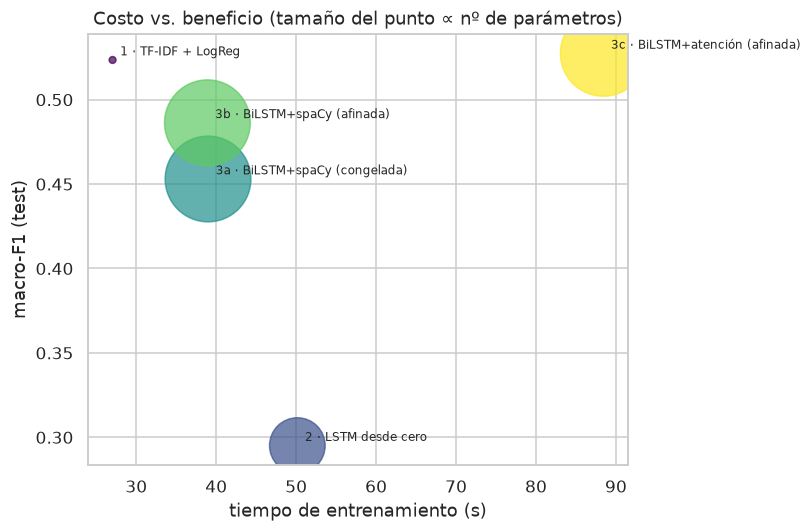

In [61]:
# Gráfica costo (tiempo/parámetros) vs. beneficio (macro-F1).
core = tabla_global[~tabla_global["modelo"].str.startswith("Baseline")].dropna(subset=["n_params"])
fig, ax = plt.subplots(figsize=(7.5, 5))
ax.scatter(core["segundos"], core["macro_f1"], s=core["n_params"] / 3000, alpha=0.7,
          c=range(len(core)), cmap="viridis")
for _, r in core.iterrows():
    ax.annotate(r["modelo"], (r["segundos"], r["macro_f1"]), fontsize=8,
               xytext=(5, 3), textcoords="offset points")
ax.set_xlabel("tiempo de entrenamiento (s)"); ax.set_ylabel("macro-F1 (test)")
ax.set_title("Costo vs. beneficio (tamaño del punto ∝ nº de parámetros)")
plt.tight_layout(); plt.show()


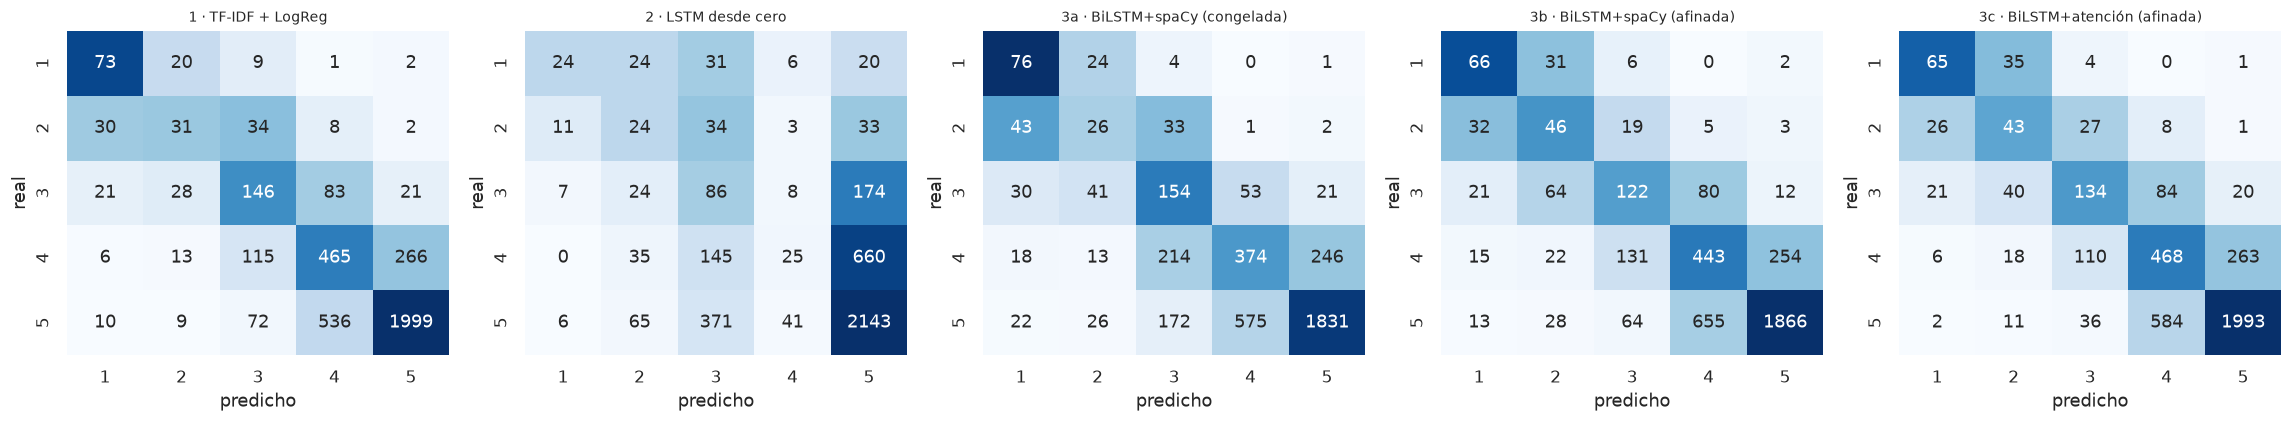

In [62]:
# Matrices de confusión de los modelos principales, lado a lado.
core_nombres = [m for m in PREDS if not m.startswith("Baseline")]
n = len(core_nombres)
fig, axes = plt.subplots(1, n, figsize=(4.2 * n, 4))
if n == 1:
    axes = [axes]
for ax, nombre in zip(axes, core_nombres):
    yt, yp = PREDS[nombre]
    cm = confusion_matrix(yt, yp, labels=ESTRELLAS)
    sns.heatmap(cm / cm.sum(1, keepdims=True), annot=cm, fmt="d", cmap="Blues", cbar=False,
                xticklabels=ESTRELLAS, yticklabels=ESTRELLAS, ax=ax)
    ax.set_title(nombre, fontsize=9); ax.set_xlabel("predicho"); ax.set_ylabel("real")
plt.tight_layout(); plt.show()


In [63]:
# =========================================================================
# 14 · Análisis cualitativo: ejemplos mal clasificados agrupados por causa
# =========================================================================
textos_test = sub.iloc[SPLIT_A["test"]]["texto"].values

def muestra_errores(nombre_modelo, n=3):
    yt, yp = PREDS[nombre_modelo]
    mal = np.where(yt != yp)[0]
    fijar_semilla()
    elegidos = np.random.choice(mal, size=min(n, len(mal)), replace=False)
    for i in elegidos:
        print(f"[real {yt[i]}★ / predicho {yp[i]}★]  {textos_test[i][:200]}...")
    print()

print(f"Errores de {MEJOR_ARQ_NOMBRE}:")
muestra_errores(MEJOR_ARQ_NOMBRE)


Errores de 3b · BiLSTM+spaCy (afinada):
[real 3★ / predicho 2★]  Me gustaba más antes. Es un lugar en el campo, el acceso solo en vehículo.
La verdad ya no me gusto las porciones son cada ves menores y el sazón malo.
Pienso que un bueno platillo tiene que ver con e...
[real 2★ / predicho 3★]  Es bueno pero muy incómodo! !!. La atención del personal es muy buena, pero las camas son super incómodas,  la que nos tocó se sentía con los resortes salidos, por otro lado los baños de hombres son c...
[real 5★ / predicho 4★]  Ir a caminar!. Una pasarela hermosa y relajante, le permite alejarse de la playa por un rato y disfrutar de la brisa!...



In [64]:
# =========================================================================
# 14 · Casos donde TODOS los modelos principales fallan
# =========================================================================
yt_ref = PREDS[core_nombres[0]][0]
fallos = np.ones(len(yt_ref), dtype=bool)
for nombre in core_nombres:
    yt_m, yp_m = PREDS[nombre]
    fallos &= (yt_m != yp_m)

print(f"Reseñas donde fallan los {len(core_nombres)} modelos principales: "
      f"{fallos.sum()} de {len(yt_ref)} ({fallos.sum() / len(yt_ref) * 100:.1f}%)")

fijar_semilla()
idxs = np.where(fallos)[0]
if len(idxs) > 0:
    for i in np.random.choice(idxs, size=min(4, len(idxs)), replace=False):
        print(f"[real {yt_ref[i]}★]  {textos_test[i][:220]}...")
        for nombre in core_nombres:
            print(f"   {nombre}: predijo {PREDS[nombre][1][i]}★")
        print()


Reseñas donde fallan los 5 modelos principales: 342 de 4000 (8.6%)
[real 3★]  Buena ubicación. Si bien llegamos por recomendación de nuestro taxista desde Puerto Vallarta, le faltó sabor a mi pasta putanesca y a los mejillones de mi esposa. 
Atención amable y linda vista hacia la playa. Ubicación ...
   1 · TF-IDF + LogReg: predijo 5★
   2 · LSTM desde cero: predijo 5★
   3a · BiLSTM+spaCy (congelada): predijo 4★
   3b · BiLSTM+spaCy (afinada): predijo 4★
   3c · BiLSTM+atención (afinada): predijo 4★

[real 5★]  Para los amantes de los paisajes. No es un lago para hacer algo, sólo para verlos, pero tiene vistas muy bonitas y los tauramaras que están en el lago dan buen precio y super lindas sus artesanías, ya que si vas a otros ...
   1 · TF-IDF + LogReg: predijo 3★
   2 · LSTM desde cero: predijo 3★
   3a · BiLSTM+spaCy (congelada): predijo 3★
   3b · BiLSTM+spaCy (afinada): predijo 3★
   3c · BiLSTM+atención (afinada): predijo 4★

[real 4★]  Viaje de graduación. Excelente servicio y 

**Hallazgos de esta sección.**

- **Ranking por macro-F1 (Split A, test):** 3c BiLSTM+atención (0,527) > TF-IDF+LogReg
  (0,524) > 3b BiLSTM afinada (0,486) > 3a BiLSTM congelada (0,453) > LSTM desde cero (0,295)
  > azar estratificado (0,193) > clase mayoritaria (0,159).
- **El dato que más sorprende:** de los cuatro modelos recurrentes, solo el que tiene
  atención supera a TF-IDF. Cambiar la arquitectura (LSTM → BiLSTM → embeddings
  preentrenados) fue subiendo el macro-F1 gradualmente sin llegar a superar la bolsa de
  palabras clásica; lo que finalmente lo logra es cambiar *cómo se lee* la secuencia:
  dejar que el modelo pese cada palabra en vez de resumir la reseña entera en un solo vector.
- **Costo vs. beneficio:** TF-IDF entrena en 27 s sin GPU y con 60.000 parámetros dispersos;
  la BiLSTM con atención tarda 88 s y tiene 9,4 millones de parámetros para ganarle por apenas
  0,004 de macro-F1. En un contexto de producción con restricciones de cómputo, TF-IDF seguiría
  siendo una opción defendible; la ganancia de la BiLSTM+atención se justifica sobre todo por
  lo que aporta en interpretabilidad (Extensión C), no solo por el número.
- **Causas de error, de las reseñas inspeccionadas:** texto de sentimiento mixto (elogio y
  queja en la misma reseña, anticipado ya en el EDA al leer la reseña cruda de 3★), reseñas
  cortas o ambiguas donde el "tono" no se decanta claramente, e incoherencias entre el texto y
  la estrella asignada por el autor (ruido de etiqueta, ya cuantificado en el EDA §3.7b: ~15%
  de las reseñas de 1★ usan vocabulario muy positivo).
- **El 8,6% de las reseñas de test (342 de 4.000) engañan a los cinco modelos principales a
  la vez.** Esa cifra es, en la práctica, un techo de rendimiento que no depende de la
  arquitectura: son casos donde el propio texto no predice bien la estrella (p. ej. una
  reseña de "viaje de graduación" con lenguaje entusiasta pero calificada 4★, no 5★, por su
  autor). Ningún modelo de texto puede recuperar información que no está en el texto.

---

## 15. Conclusiones

**1. Respuesta a la pregunta de la Sección 0.** Sí es posible predecir la polaridad de una
reseña turística en español a partir de su texto, muy por encima del azar (macro-F1 0,49-0,53
frente a 0,16-0,19 de los baselines), pero con un techo claro impuesto por la tarea misma: el
mejor modelo de este notebook (BiLSTM + atención, macro-F1 0,527) sigue muy lejos del 0,949
que la misma arquitectura logra sobre `Type`, una tarea balanceada y no ordinal. La brecha es
la respuesta central del notebook: **el problema es difícil por su desbalance extremo y su
naturaleza ordinal, no por falta de una arquitectura adecuada.**

**2. Qué aporta cada nivel de representación, en esta tarea concreta.** La escalera de
complejidad no fue monótona: pasar de TF-IDF a LSTM y luego a BiLSTM con embeddings
preentrenados *no* superó a la bolsa de palabras clásica (0,524) hasta que se sumó una capa de
atención (0,527). El orden de las palabras y los embeddings preentrenados por sí solos no
bastaron; lo que marcó la diferencia fue dejar que el modelo decidiera a qué palabras
atender, en vez de comprimir la reseña completa en un único vector oculto.

**3. Qué reveló el tratamiento ordinal (Extensión A).** Formular la salida como regresión con
umbrales o como clasificación ordinal acumulativa (CORAL) no mejora mucho el macro-F1 sobre
cross-entropy (+0,01), pero reduce a la mitad los errores graves (a dos estrellas o más de
distancia: de 4,8% a ~3,1%) y mejora sustancialmente MAE y QWK. Para una escala de estrellas,
esto importa más que el macro-F1 solo: es preferible un modelo que se equivoca por poco a uno
que acierta la clase exacta algo más seguido pero falla catastróficamente el resto de las
veces.

**4. Qué reveló la evaluación geográfica (Extensión B).** Contra la hipótesis de partida, el
macro-F1 **no cayó** al evaluar sobre regiones (Chiapas, Baja California Sur, Querétaro)
completamente ausentes del entrenamiento - subió ligeramente (+0,043). La inspección
cualitativa de errores no mostró señales de que el modelo dependiera de topónimos, lo que es
consistente con (aunque no prueba de forma concluyente) que el modelo aprende vocabulario de
sentimiento genuino y no memoriza destinos. Es un resultado honesto que contradice la
hipótesis del EDA, y se reporta como tal.

**5. Qué reveló el contraste con la tarea de control (Sección 13).** La misma arquitectura sin
cambios pasa de macro-F1 0,486 en polaridad a 0,949 en `Type`. Es la evidencia más contundente
del notebook de que la dificultad reside en la tarea (desbalance, ordinalidad, ruido de
etiqueta) y no en el modelo ni en el preprocesamiento.

**6. Qué reveló el espacio de embeddings (Extensión D).** El afinado de los embeddings
reorganiza selectivamente el espacio: mueve los adjetivos de sentimiento (de donde sale la
señal de la tarea, confirmado también por la Extensión C) y apenas toca los sustantivos
temáticos de dominio (*sargazo*, *alberca*, *mesero*), que aparecen parejo en todas las
polaridades. La aritmética vectorial de dominio (`sucio - malo + excelente ≈ impecable`)
funciona igual de bien en ambos espacios, lo que sugiere que los vectores preentrenados de
propósito general ya capturan buena parte de la estructura de sentimiento sobre adjetivos
comunes del español.

### Limitaciones (honestas)

- **Submuestra de 40.000 reseñas**, no el corpus completo (208.051). Las clases 1★ y 2★
  quedan con solo ~1.050 ejemplos de entrenamiento cada una; sus métricas son las más
  sensibles a esta limitación.
- **Un solo corpus, un solo dominio, una variedad del español** (turismo mexicano). Los
  hallazgos sobre vocabulario, sesgo geográfico y ruido de etiqueta no necesariamente
  generalizan a otros dominios de reseñas.
- **Ruido de etiqueta inherente** a reseñas autoasignadas por el propio autor en TripAdvisor:
  el EDA cuantificó que ~15% de las reseñas de 1★ usan vocabulario fuertemente positivo (y
  viceversa en menor medida), lo que pone un techo al macro-F1 alcanzable por cualquier
  modelo que solo vea texto.
- **Exploración de hiperparámetros acotada** por el presupuesto de cómputo (una corrida por
  configuración, sin búsqueda sistemática): las comparaciones entre modelos son válidas
  porque todos comparten protocolo, pero los números absolutos podrían mejorar con más
  ajuste.
- **Extensión B con una sola partición geográfica**: tres regiones de polaridad media similar
  al resto del corpus. No se puede descartar que una partición sobre regiones con sesgo de
  polaridad más marcado sí muestre una caída de rendimiento.
- **Modelo 4 (BETO/transformer) fuera de alcance** por indicación explícita del profesor para
  esta entrega (`docs/DECISIONS.md` §D-009), no por limitación técnica.

### Trabajo futuro

- Repetir la Extensión B con una partición geográfica elegida por polaridad media extrema
  (en vez de por tamaño de región), para aislar mejor el efecto de la generalización
  geográfica del efecto del desbalance de etiquetas.
- Fine-tuning de BETO (Modelo 4 original del SPEC) como techo superior de referencia, ahora
  que el resto de la escalera de modelos y el protocolo de evaluación ya están validados.
  Un LLM open source de instrucciones, usado en modo *zero-shot* o *few-shot* sobre las
  mismas métricas, sería otro techo de comparación interesante y cada vez más accesible.
  Una demo interactiva (Gradio/Streamlit) que reciba una reseña nueva y muestre la
  predicción de polaridad junto con la visualización de atención de la Extensión C.
- Detección automática de reseñas con ruido de etiqueta (texto y estrella incoherentes) como
  paso de limpieza previo al entrenamiento, en vez de solo cuantificarlo post-hoc en el
  análisis de errores.